# Is LD3 a left/right forepaw axis?

`clustering/data_files/mouse_LDA_5_bins_25_18-09-2026` — 269 sessions, 58 mice, LD1…LD25.
The claim under test is that **LD3 separates mice by which forepaw they move more**.

Three views of the same behaviour, at increasing distance from the embedding:

| | what it is | independent of the LDA? |
|---|---|---|
| **syllable use** | occupancy of the 8 HMM paw states — the LDA's own input | no — this is the *mechanism*, what inside the design matrix LD3 reads |
| **paw wavelets** | 0.5–8 Hz velocity band power per paw, per session | different representation, same cameras, no HMM and no trial structure |
| **paw position** | postural spread / excursion of each paw around its own resting point | different representation *and* a different kind of measure (position, not velocity) |

**The confound that governs every number below.** The two forepaws are seen by two
different cameras (left 1280×1024, right 640×512) with different tracking-noise floors
and a multiplicative gain difference. `segmentation/paw_bias` established that the
*population mean* of any laterality index here is instrumental and means nothing, and
that the raw amplitude index correlates r ≈ +0.8 with the 32 Hz tracking-noise index.
Only *individual differences* are interpretable, and only after partialling the noise
index out. Gain-invariant measures (bout rate at matched duty cycle, spectral shape,
lead–lag) are reported alongside because a multiplicative per-camera error cannot touch
them.

In [1]:
"""
CONFIGURATION -- every path and threshold this notebook depends on
==================================================================
Companion module: laterality_features.py (in this folder) does the per-session feature
extraction and caches it to paw_laterality_sessions.csv, so a re-run of this notebook
costs seconds rather than minutes.

RELATED WORK ALREADY IN THE REPO, so this notebook does not re-derive it:
  segmentation/paw_bias/          the paw-bias metrics, their validation and the camera
                                  artefact analysis. README.md there is the reference.
  lab/lda1_vs_raw_paw_laterality.py   the same question asked of LD1 and LD2, against
                                  raw design-matrix positions. This notebook is its LD3
                                  counterpart and reuses its conventions and its
                                  state-LI definition.
"""
LDA_FILE       = 'clustering/data_files/mouse_LDA_5_bins_25_18-09-2026'
SYLLABLE_FILE  = 'data/8_k_10_bin_syllables_19-08-2026'
LD_MAX         = 8        # how many LDs to screen; the embedding has 25
N_PERM         = 10000
ALPHA          = 0.05
EPOCHS         = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']   # pipeline order
N_BINS         = 10       # time bins per epoch in the syllable file
SAVE_FIGS      = False    # True writes to paper-individuality/figures/laterality/

In [2]:
"""IMPORTS AND PATHS"""
import sys
import pathlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = pathlib.Path.cwd()
if HERE.name != 'laterality':          # tolerate being run from the repo root
    HERE = next(p for p in [HERE, *HERE.parents]
                if (p / 'paper-individuality').exists()) / 'paper-individuality/4_mice/laterality'
ROOT = HERE.parent.parent              # .../paper-individuality

# A long-lived kernel caches modules, so edits to laterality_features.py or paper_style.py
# stay invisible until a restart -- reload explicitly, as the other pipeline notebooks do.
for _p in (str(HERE), str(ROOT), str(ROOT / '4_mice'), str(ROOT / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps
import laterality_features as lf
importlib.reload(ps)
importlib.reload(lf)
ps.use('paper')

print('paper-individuality at', ROOT)

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi
paper-individuality at /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality


## 0. The embedding

269 sessions from 58 mice — the `>= 3 sessions` cohort the saved embedding was fit on.
Columns `0..24` become `LD1..LD25`.

**A caveat the pipeline itself raises.** The leading LDA eigenvalues are near-tied, and
near-tied axes are free to rotate among themselves; the notebook that produced this file
says to read them as a subspace rather than as individual axes. So the honest question is
not only "does LD3 track laterality" but "is laterality confined to LD3, or spread over
the leading subspace" — screened in section 5.

In [3]:
lda = pd.read_pickle(ROOT / LDA_FILE)
lda = lda.rename(columns={i: f'LD{i + 1}' for i in range(25)}).set_index('session')
LDS = [f'LD{k}' for k in range(1, LD_MAX + 1)]

print(f'{len(lda)} sessions, {lda.mouse_name.nunique()} mice, {lda.lab.nunique()} labs')
print('sessions per mouse:',
      lda.groupby('mouse_name').size().describe()[['min', '50%', 'max']].to_dict())
lda[LDS].describe().T[['mean', 'std', 'min', 'max']].round(2)

269 sessions, 58 mice, 10 labs
sessions per mouse: {'min': 3.0, '50%': 4.0, 'max': 16.0}


,mean,std,min,max
LD1,0.43,3.37,-10.38,8.83
LD2,0.16,3.03,-9.33,6.80
LD3,0.08,2.55,-10.02,8.27
LD4,0.33,2.68,-7.68,9.24
LD5,0.06,2.37,-5.64,5.47
LD6,-0.04,2.40,-7.12,5.56
LD7,0.02,2.00,-5.91,8.47
LD8,-0.20,2.20,-6.84,4.24


## 1. Which of the 8 HMM paw states are lateralised?

Not assumed — recomputed from `segmentation/paw_bias/state_profiles_19Ago2026.csv`, which
holds each state's mean session-z-scored wavelet power for every (paw, axis, frequency).
`LI` averages the 10 left-paw columns against the 10 right-paw ones.

Two states are clearly left (3, 5) and two clearly right (4, 6); the rest are bilateral —
quiescence (0), low-amplitude (1), slow bilateral (2) and the rare all-out state (7).

,left,right,overall,LI
state,,,,
0,-0.617,-0.599,-0.608,-0.015
1,-0.152,-0.197,-0.175,0.129
2,0.758,0.635,0.697,0.088
3,0.864,0.194,0.529,0.633
4,0.043,0.429,0.236,-0.818
5,2.015,1.059,1.537,0.311
6,0.682,1.634,1.158,-0.411
7,2.939,3.446,3.192,-0.079


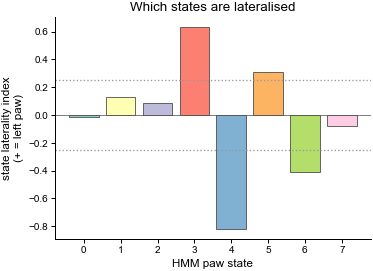

In [4]:
state_li = lf.state_laterality()
display(state_li.round(3))

fig, ax = ps.figure('single')
cols = [ps.SYLLABLE_COLORS[i] for i in state_li.index]
ax.bar(state_li.index, state_li.LI, color=cols, edgecolor='0.3', lw=0.5)
for thr, ls in [(0.25, ':'), (-0.25, ':')]:
    ax.axhline(thr, color='0.6', ls=ls, lw=0.8)
ps.zero_line(ax)
ax.set(xlabel='HMM paw state', ylabel='state laterality index\n(+ = left paw)',
       title='Which states are lateralised')
plt.show()

## 2. Syllable use along LD3

Per-session occupancy of the 8 paw states, from the same file the LDA is built on
(`state = value % 8`, the decomposition the pipeline's own `binarize()` uses). Two
indices:

* `state_LI` — the two left states against the two right ones (the definition
  `lab/lda1_vs_raw_paw_laterality.py` uses, kept identical so the two are comparable).
* `occ_LI` — every state weighted by *its own* profile LI, so the weakly lateralised
  states contribute in proportion rather than being discarded.

The panel that matters is the second one: if LD3 is a laterality axis, a state's
correlation with LD3 should be a straight function of how lateralised that state is.

In [5]:
occ, _sli, left_states, right_states = lf.syllable_features(
    ROOT / SYLLABLE_FILE, sessions=lda.index, state_li=state_li)
print(f'left states {left_states}, right states {right_states}')
print(f'{len(occ)} sessions;  state_LI vs occ_LI  r = '
      f'{occ.state_LI.corr(occ.occ_LI):.3f}')
occ[[f'state{i}' for i in range(8)] + ['whisk', 'lick', 'state_LI', 'occ_LI']].describe().T.round(3)

left states [3, 5], right states [4, 6]
269 sessions;  state_LI vs occ_LI  r = 0.962


,count,mean,std,min,25%,50%,75%,max
state0,269.0,0.116,0.053,0.026,0.077,0.108,0.150,0.395
state1,269.0,0.394,0.056,0.170,0.356,0.389,0.427,0.573
state2,269.0,0.132,0.056,0.027,0.095,0.123,0.163,0.387
state3,269.0,0.093,0.045,0.010,0.060,0.091,0.117,0.297
state4,269.0,0.130,0.056,0.017,0.091,0.128,0.161,0.382
state5,269.0,0.052,0.026,0.005,0.033,0.049,0.069,0.168
state6,269.0,0.075,0.027,0.007,0.059,0.076,0.093,0.195
state7,269.0,0.007,0.005,0.000,0.003,0.006,0.010,0.027
whisk,269.0,0.588,0.122,0.333,0.493,0.574,0.670,0.929
lick,269.0,0.195,0.084,0.023,0.142,0.190,0.248,0.479


,state_LI,occupancy,r_LD3,p_LD3
s,,,,
0,-0.015,0.112,0.204,0.124
1,0.129,0.390,-0.269,0.041
2,0.088,0.135,-0.265,0.045
3,0.633,0.091,-0.445,0.000
4,-0.818,0.135,0.608,0.000
5,0.311,0.052,-0.152,0.256
6,-0.411,0.079,0.165,0.216
7,-0.079,0.007,-0.178,0.181


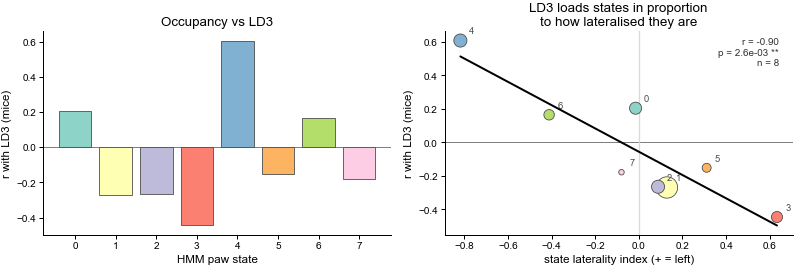

In [6]:
"""
PER-STATE: does a state's relation to LD3 follow how lateralised the state is?
This is the mechanism panel -- it says what inside the design matrix LD3 is reading.
One point per MOUSE, since sessions of one mouse are not independent.
"""
df = lda.join(occ)
mouse_occ = df.groupby('mouse_name').mean(numeric_only=True)

r_state = pd.DataFrame({
    's': range(8),
    'state_LI': state_li.LI.values,
    'occupancy': [mouse_occ[f'state{i}'].mean() for i in range(8)],
    'r_LD3': [stats.pearsonr(mouse_occ.LD3, mouse_occ[f'state{i}'])[0] for i in range(8)],
    'p_LD3': [stats.pearsonr(mouse_occ.LD3, mouse_occ[f'state{i}'])[1] for i in range(8)],
}).set_index('s')
display(r_state.round(3))

fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['single'][0] * 2,
                                        ps.SIZES[ps.MODE]['single'][1]))
ax = axes[0]
ax.bar(r_state.index, r_state.r_LD3, color=[ps.SYLLABLE_COLORS[i] for i in r_state.index],
       edgecolor='0.3', lw=0.5)
ps.zero_line(ax)
ax.set(xlabel='HMM paw state', ylabel='r with LD3 (mice)', title='Occupancy vs LD3')

ax = axes[1]
# marker area ~ occupancy: a state occupied 0.7% of the time cannot move an axis much,
# and without that cue state 7 reads as an equal member of the pattern
ax.scatter(r_state.state_LI, r_state.r_LD3,
           s=400 * r_state.occupancy + 8,
           c=[ps.SYLLABLE_COLORS[i] for i in r_state.index], edgecolors='0.3', lw=0.5,
           zorder=3)
for i, row in r_state.iterrows():
    ax.annotate(str(i), (row.state_LI, row.r_LD3), textcoords='offset points',
                xytext=(5, 4), fontsize=plt.rcParams['font.size'] * 0.8, color='0.3')
_r, _p = stats.pearsonr(r_state.state_LI, r_state.r_LD3)
ps.regline(ax, r_state.state_LI, r_state.r_LD3, _p < ALPHA)
ps.annotate_corr(ax, _r, _p, n=len(r_state), loc='upper right')
ps.zero_line(ax)
ax.axvline(0, color='0.85', lw=0.8, zorder=0)
ax.set(xlabel='state laterality index (+ = left)', ylabel='r with LD3 (mice)',
       title='LD3 loads states in proportion\nto how lateralised they are')
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_state_laterality', subdir='laterality')
plt.show()

## 3. Where in the trial does it live?

The design matrix is 4 epochs × 10 bins × (8 paw states + whisk + lick). Correlating each
cell with LD3 across mice shows whether laterality is a whole-session trait or something
that appears at a particular moment of the trial.

This rebuilds the per-(epoch, bin, channel) occupancy from the raw sequences rather than
re-running the pipeline, so it is a **reconstruction** of the design matrix, not the exact
matrix the LDA saw: the reference-state column is not dropped and no lab correction is
applied. Neither affects a correlation map.

In [7]:
"""Per-session occupancy of every (epoch, time bin, channel), then r with LD3 across mice."""
seq = pd.read_parquet(ROOT / SYLLABLE_FILE,
                      columns=['sample', 'broader_label', 'binned_sequence'])
seq['session'] = seq['sample'].str[:36]
seq = seq[seq.session.isin(lda.index)]

CHANNELS = [f'Paw {i}' for i in range(8)] + ['Whisk', 'Lick']
cells = {}
for (sess, epoch), g in seq.groupby(['session', 'broader_label']):
    if epoch not in EPOCHS:
        continue
    v = np.vstack([np.asarray(s, float) for s in g['binned_sequence'].values])  # trials x bins
    ok = np.isfinite(v)
    iv = np.where(ok, v, 0).astype(int)
    for b in range(v.shape[1]):
        n = ok[:, b].sum()
        if n == 0:
            continue
        col = iv[ok[:, b], b]
        occ_b = np.bincount(col % 8, minlength=8) / n
        cells[(sess, epoch, b)] = np.r_[occ_b, ((col // 8) % 2).mean(), (col // 16).mean()]

M = pd.DataFrame(cells).T
M.index.names = ['session', 'epoch', 'bin']
M.columns = CHANNELS
print(f'reconstructed design matrix: {M.index.get_level_values("session").nunique()} sessions '
      f'x {len(EPOCHS)} epochs x {N_BINS} bins x {len(CHANNELS)} channels')

# one row per mouse per (epoch, bin), so the map is not pseudo-replicated
Mm = (M.join(lda[['mouse_name']], on='session')
        .groupby(['mouse_name', 'epoch', 'bin']).mean())
ld3_mouse = lda.groupby('mouse_name').LD3.mean()

rmap = np.full((len(CHANNELS), len(EPOCHS) * N_BINS), np.nan)
for j, ep in enumerate(EPOCHS):
    for b in range(N_BINS):
        try:
            sub = Mm.xs((ep, b), level=('epoch', 'bin'))
        except KeyError:
            continue
        y = ld3_mouse.reindex(sub.index)
        for i, ch in enumerate(CHANNELS):
            m = np.isfinite(sub[ch]) & np.isfinite(y)
            if m.sum() > 10 and sub[ch][m].std() > 0:
                rmap[i, j * N_BINS + b] = stats.pearsonr(sub[ch][m], y[m])[0]

reconstructed design matrix: 269 sessions x 4 epochs x 10 bins x 10 channels


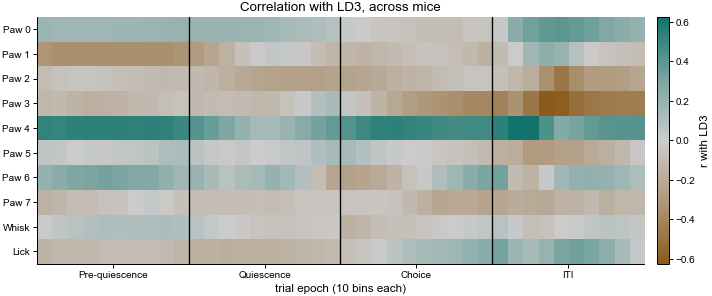

mean r per channel, over the whole trial (SIGNED -- the sign is the whole point):
Paw 0    0.140
Paw 1   -0.130
Paw 2   -0.176
Paw 3   -0.225
Paw 4    0.430
Paw 5   -0.024
Paw 6    0.111
Paw 7   -0.110
Whisk    0.009
Lick     0.011

spread of r across the 40 time bins (SD), per channel -- small = a whole-session trait, large = something that happens at a moment:
Paw 0    0.133
Paw 1    0.160
Paw 2    0.101
Paw 3    0.189
Paw 4    0.125
Paw 5    0.119
Paw 6    0.168
Paw 7    0.068
Whisk    0.071
Lick     0.166


In [8]:
fig, ax = plt.subplots(figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.8,
                                ps.SIZES[ps.MODE]['single'][1] * 1.1))
vmax = np.nanmax(np.abs(rmap))
im = ax.imshow(rmap, aspect='auto', cmap=ps.CORR_CMAP, norm=ps.corr_norm(vmax),
               interpolation='none')
ax.set_yticks(range(len(CHANNELS)), CHANNELS)
ax.set_xticks(np.arange(len(EPOCHS)) * N_BINS + N_BINS / 2 - 0.5, EPOCHS)
for j in range(1, len(EPOCHS)):
    ax.axvline(j * N_BINS - 0.5, color='k', lw=0.8)
ax.set(xlabel='trial epoch (10 bins each)', title='Correlation with LD3, across mice')
fig.colorbar(im, ax=ax, label='r with LD3', fraction=0.03, pad=0.02)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_design_matrix_map', subdir='laterality')
plt.show()

print('mean r per channel, over the whole trial (SIGNED -- the sign is the whole point):')
print(pd.Series(np.nanmean(rmap, axis=1), index=CHANNELS).round(3).to_string())
print('\nspread of r across the 40 time bins (SD), per channel -- '
      'small = a whole-session trait, large = something that happens at a moment:')
print(pd.Series(np.nanstd(rmap, axis=1), index=CHANNELS).round(3).to_string())

## 4. Raw paw position and wavelets

Straight from `data/paw_wavelets/`, one file per session, carrying both the raw forepaw
coordinates and the velocity wavelets. Computed on the frames where **both** paws are
tracked, so a dropout on one camera cannot shift the index; NaNs are dropped, never
interpolated.

* `li_bandpow` — 0.5–8 Hz velocity power, left against right. The amplitude measure.
* `li_noisepow` — 32 Hz power. A forepaw cannot oscillate at 32 Hz, so this is the
  tracking-noise / camera-gain proxy, and it is the confound.
* `li_exc`, `li_possd`, `li_posiqr` — **position**, not velocity: how far each paw ranges
  around its own resting place, resolution-corrected (left-camera pixels halved).

The first cell checks the extraction against `segmentation/paw_bias/paw_bias_sessions.csv`,
which computed `li_bandpow` and `li_noisepow` independently.

In [9]:
paw = lf.paw_features(sessions=lda.index)
pb = lf.paw_bias_metrics(lda.index)          # validated metrics, '_pb'-suffixed

for a in ('li_bandpow', 'li_noisepow'):
    m = np.isfinite(paw[a]) & np.isfinite(pb[f'{a}_pb'])
    print(f'  {a}: r = {stats.pearsonr(paw[a][m], pb[f"{a}_pb"][m])[0]:.4f} vs paw_bias, '
          f'max |diff| = {np.abs(paw[a][m] - pb[f"{a}_pb"][m]).max():.2e}  (n = {m.sum()})')

print(f'\nsplit-half reliability of li_bandpow within a session: '
      f'r = {stats.pearsonr(paw.li_bandpow_h1, paw.li_bandpow_h2)[0]:.3f}'
      '   <- the measurement ceiling any correlation below is judged against')
print('li_bandpow across sessions: mean %+.3f, sd %.3f   <- the MEAN is instrumental '
      '(camera gain); only the spread is usable'
      % (paw.li_bandpow.mean(), paw.li_bandpow.std()))

data = lda.join(occ).join(paw).join(pb)
print(f'\njoined table: {data.shape[0]} sessions, '
      f'{data.li_bandpow.notna().sum()} with paw features')

136 wavelet files under /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/paw_wavelets; 60 sessions to extract (209 of the requested sessions have no wavelet file)
  ... 50/60
wrote /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/4_mice/laterality/paw_laterality_sessions.csv (60, 32)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/segmentation/paw_bias/paw_bias_sessions.csv'

## 5. Does LD3 track laterality?

Every measure against LD1…LD8, at the **mouse** level — one point per mouse, the unit that
is not pseudo-replicated (sessions of one mouse are not independent, and section 6 repeats
this at the session level with a mouse-yoked permutation to show it does not depend on the
choice).

`p_perm` shuffles the laterality measure across mice; `p_fdr` is Benjamini–Hochberg across
all measure × LD cells in the table.

In [ ]:
MEASURES = {
    'state_LI':        'syllable: left-states − right-states',
    'occ_LI':          'syllable: LI-weighted occupancy',
    'li_bandpow':      'wavelet: 0.5–8 Hz power LI',
    'li_pow_4.0':      'wavelet: 4 Hz power LI',
    'li_exc':          'position: excursion LI',
    'li_possd':        'position: spread LI',
    'li_snr':          'wavelet: SNR LI (gain-invariant, over-corrects)',
    'li_boutrate_pb':  'bouts at matched duty cycle (gain-invariant)',
    'li_shape_4.0_pb': 'spectral shape at 4 Hz (gain-invariant)',
    'lag_s_pb':        'lead–lag, + = left leads (gain-invariant)',
    'xcorr_peak_pb':   'bilateral coupling (not lateralised)',
    'li_noisepow':     '32 Hz tracking noise LI  ⚠ THE CONFOUND',
}

def corr_report(x, y, n_perm=N_PERM, seed=0, groups=None):
    """Pearson r with a permutation p. `groups` (one label per row) shuffles whole
    groups and keeps rows within a group yoked -- the session-level test, where a
    plain shuffle would treat the sessions of one mouse as independent."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if groups is not None:
        groups = np.asarray(groups)[ok]
    x, y = x[ok], y[ok]
    if len(x) < 5 or x.std() == 0 or y.std() == 0:
        return dict(n=len(x), r=np.nan, p=np.nan, p_perm=np.nan)
    r, p = stats.pearsonr(x, y)
    rng = np.random.default_rng(seed)
    if groups is None:
        null = [abs(np.corrcoef(rng.permutation(x), y)[0, 1]) for _ in range(n_perm)]
    else:
        # one value per group, shuffled across groups, then broadcast back to its rows
        gl, gi = np.unique(groups, return_inverse=True)
        gy = np.array([y[gi == k].mean() for k in range(len(gl))])
        null = []
        for _ in range(n_perm):
            null.append(abs(np.corrcoef(x, rng.permutation(gy)[gi])[0, 1]))
    p_perm = (np.sum(np.asarray(null) >= abs(r)) + 1) / (n_perm + 1)
    return dict(n=len(x), r=r, p=p, p_perm=p_perm)


def fdr(p):
    """Benjamini-Hochberg q-values, NaNs passed through."""
    p = np.asarray(p, float)
    out = np.full(p.shape, np.nan)
    ok = np.isfinite(p)
    o = np.argsort(p[ok])
    q = p[ok][o] * ok.sum() / (np.arange(ok.sum()) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    tmp = np.empty(ok.sum()); tmp[o] = np.minimum(q, 1)
    out[ok] = tmp
    return out

In [ ]:
mouse = data.groupby('mouse_name').mean(numeric_only=True)
mouse['lab'] = data.groupby('mouse_name')['lab'].first()
print(f'{len(mouse)} mice')

rows = []
for meas, label in MEASURES.items():
    for ld in LDS:
        rows.append(dict(measure=meas, label=label, LD=ld,
                         **corr_report(mouse[ld], mouse[meas])))
screen = pd.DataFrame(rows)
screen['p_fdr'] = fdr(screen.p_perm)

piv_r = screen.pivot(index='measure', columns='LD', values='r').loc[list(MEASURES)][LDS]
piv_q = screen.pivot(index='measure', columns='LD', values='p_fdr').loc[list(MEASURES)][LDS]
display(piv_r.round(3).style.format('{:+.3f}')
        .background_gradient(cmap=ps.CORR_CMAP, vmin=-0.7, vmax=0.7)
        .set_caption('Pearson r, mouse level (n = %d). Cells below are FDR q.' % len(mouse)))
display(piv_q.round(4))

58 mice


LD,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
measure,,,,,,,,
state_LI,+0.264,-0.039,-0.606,+0.373,+0.040,+0.121,-0.392,-0.286
occ_LI,+0.327,-0.112,-0.631,+0.346,+0.055,+0.169,-0.307,-0.369
li_bandpow,+0.224,-0.298,-0.615,+0.262,+0.013,+0.188,-0.201,-0.232
li_pow_4.0,+0.201,-0.292,-0.624,+0.296,-0.013,+0.193,-0.182,-0.214
li_exc,+0.101,+0.044,+0.002,-0.000,+0.262,+0.023,-0.064,-0.033
li_possd,+0.053,+0.001,+0.049,-0.107,+0.249,-0.009,-0.037,-0.031
li_snr,+0.245,+0.044,-0.252,+0.135,+0.007,+0.158,+0.119,-0.050
li_boutrate_pb,+0.045,-0.130,+0.240,-0.217,+0.018,-0.005,+0.276,-0.033
li_shape_4.0_pb,-0.050,-0.073,-0.363,+0.412,-0.186,+0.140,+0.032,+0.023


LD,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8
measure,,,,,,,,
state_LI,0.1739,0.9433,0.0024,0.0331,0.9433,0.6047,0.0331,0.1252
occ_LI,0.0751,0.6468,0.0024,0.0487,0.9431,0.4209,0.1029,0.0401
li_bandpow,0.2485,0.1142,0.0024,0.1739,0.9955,0.3570,0.3076,0.2154
li_pow_4.0,0.3076,0.1179,0.0024,0.1142,0.9955,0.3479,0.3621,0.2620
li_exc,0.6747,0.9433,0.9969,0.9969,0.1817,0.9766,0.9176,0.9433
li_possd,0.9431,0.9969,0.9431,0.6617,0.1908,0.9955,0.9433,0.9502
li_snr,0.1908,0.9433,0.1908,0.5313,0.9969,0.4535,0.5948,0.9431
li_boutrate_pb,0.9433,0.5758,0.2025,0.2620,0.9844,0.9969,0.1532,0.9433
li_shape_4.0_pb,0.9431,0.8526,0.0473,0.0219,0.3621,0.5313,0.9433,0.9766


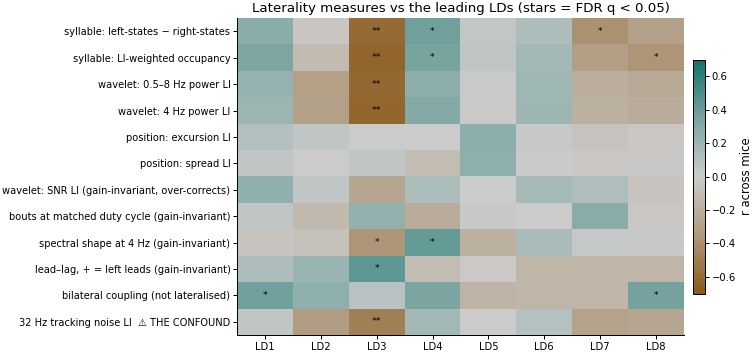

In [ ]:
fig, ax = plt.subplots(figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.9,
                                ps.SIZES[ps.MODE]['single'][1] * 1.3))
im = ax.imshow(piv_r.values, cmap=ps.CORR_CMAP, norm=ps.corr_norm(0.7),
               aspect='auto', interpolation='none')
ax.set_xticks(range(len(LDS)), LDS)
ax.set_yticks(range(len(piv_r)), [MEASURES[m] for m in piv_r.index],
              fontsize=plt.rcParams['font.size'] * 0.85)
for i in range(piv_r.shape[0]):
    for j in range(piv_r.shape[1]):
        if np.isfinite(piv_q.values[i, j]) and piv_q.values[i, j] < ALPHA:
            ax.text(j, i, ps.stars(piv_q.values[i, j]), ha='center', va='center',
                    fontsize=plt.rcParams['font.size'] * 0.8, color='k')
fig.colorbar(im, ax=ax, label='r across mice', fraction=0.025, pad=0.02)
ax.set_title('Laterality measures vs the leading LDs (stars = FDR q < %.2f)' % ALPHA)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld_screen_laterality', subdir='laterality')
plt.show()

### Is laterality *confined* to LD3?

The pipeline warns that near-tied eigenvalues leave the leading axes free to rotate among
themselves, so a second axis carrying some of the same signal is expected rather than
surprising. Two things to separate:

* how much of a measure LD3 alone explains, against LD1–LD8 jointly (if the two are close,
  LD3 is the axis; if the joint fit is much better, laterality lives in a subspace);
* where the best single direction in that subspace actually points.

In [ ]:
"""
HOW MUCH OF EACH MEASURE IS LD3, AND HOW MUCH IS THE REST OF THE SUBSPACE?

R2 from 8 predictors on 58 mice is optimistic, so the in-sample number is reported
next to an adjusted one and a 5-fold cross-validated one. The CV R2 is the one to
read: it can go NEGATIVE, which is what an 8-predictor fit on 58 points looks like
when the extra predictors are noise.
"""
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression


def _cv_r2(X, y, seed=0, n_splits=5):
    X = np.atleast_2d(X.T).T if X.ndim == 1 else X
    pred = np.empty(len(y))
    for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(X):
        pred[te] = LinearRegression().fit(X[tr], y[tr]).predict(X[te])
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def subspace_fit(y_name, lds=LDS):
    y = mouse[y_name].to_numpy(float)
    ok = np.isfinite(y)
    X = mouse.loc[ok, lds].to_numpy(float)
    y = y[ok]
    Xc = (X - X.mean(0)) / X.std(0)
    A = np.c_[np.ones(len(Xc)), Xc]
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    r2_full = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    n, p = len(y), len(lds)
    r2_adj = 1 - (1 - r2_full) * (n - 1) / (n - p - 1)
    j = lds.index('LD3')
    r2_ld3 = stats.pearsonr(X[:, j], y)[0] ** 2
    w = beta[1:] / np.linalg.norm(beta[1:])
    return dict(measure=y_name, n=n,
                r2_LD3=r2_ld3, cv_r2_LD3=_cv_r2(X[:, [j]], y),
                r2_all=r2_full, r2_all_adj=r2_adj, cv_r2_all=_cv_r2(Xc, y),
                cos_with_LD3=abs(w[j]),
                top=', '.join(f'{lds[i]} {w[i]:+.2f}' for i in np.argsort(-np.abs(w))[:3]))


sub = pd.DataFrame([subspace_fit(m) for m in
                    ['state_LI', 'occ_LI', 'li_bandpow', 'lag_s_pb']]).set_index('measure')
display(sub.round(3))
print('cos_with_LD3 = |component of the best-fitting direction that lies along LD3|.\n'
      'LD3 being the largest single component while LD1-LD8 jointly do better is exactly\n'
      'the picture the pipeline predicts: near-tied eigenvalues leave the leading axes\n'
      'free to rotate, so the laterality direction is CLOSE to LD3 rather than identical\n'
      'to it. Compare cv_r2_LD3 with cv_r2_all to see how much that costs out of sample.')

,n,r2_LD3,cv_r2_LD3,r2_all,r2_all_adj,cv_r2_all,cos_with_LD3,top
measure,,,,,,,,
state_LI,58,0.368,0.290,0.830,0.802,0.727,0.666,"LD3 -0.67, LD7 -0.43, LD4 +0.41"
occ_LI,58,0.398,0.346,0.899,0.882,0.827,0.666,"LD3 -0.67, LD8 -0.39, LD4 +0.36"
li_bandpow,58,0.378,0.302,0.716,0.669,0.482,0.727,"LD3 -0.73, LD2 -0.35, LD4 +0.31"
lag_s_pb,58,0.188,0.110,0.323,0.213,-0.292,0.762,"LD3 +0.76, LD2 +0.36, LD8 -0.28"


cos_with_LD3 = |component of the best-fitting direction that lies along LD3|.
LD3 being the largest single component while LD1-LD8 jointly do better is exactly
the picture the pipeline predicts: near-tied eigenvalues leave the leading axes
free to rotate, so the laterality direction is CLOSE to LD3 rather than identical
to it. Compare cv_r2_LD3 with cv_r2_all to see how much that costs out of sample.


## 6. The controls that decide whether to believe it

1. **The camera confound.** Partial out `li_noisepow` (32 Hz tracking noise). If the
   relation is an artefact of one camera being noisier, it dies here.
2. **Gain-invariant measures.** Bout rate at matched duty cycle, spectral shape and
   lead–lag cannot be moved by a multiplicative per-camera gain at all.
3. **Lab / rig.** Each mouse is normally recorded on one rig, so a rig-geometry effect
   would masquerade as an individual trait. Two tests: how much of each LD a lab label
   explains, and the correlation after centring every variable within its lab.
4. **Session level, mouse-yoked permutation.** Same test without averaging within mouse,
   with a null that shuffles mice rather than sessions.

One reading note for `li_snr`: it is already normalised by each paw's own 32 Hz floor, so partialling `li_noisepow` out of it is not a control but a second, differently-shaped correction of the same quantity. Its *partial* column is therefore not comparable with the others — read its raw row instead.

In [ ]:
def partial_corr(x, y, z):
    """r(x, y | z) by residualising both on z (Frisch-Waugh-Lovell), as the neural
    module does. Returns (r, p, n)."""
    x, y, z = (np.asarray(v, float) for v in (x, y, z))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    if m.sum() < 5:
        return np.nan, np.nan, int(m.sum())
    rx = x - np.polyval(np.polyfit(z, x, 1), z)
    ry = y - np.polyval(np.polyfit(z, y, 1), z)
    r, _ = stats.pearsonr(rx, ry)
    # df drops by one for the covariate, so the p from pearsonr on residuals is optimistic
    n = len(x)
    t = r * np.sqrt((n - 3) / max(1 - r ** 2, 1e-12))
    return r, 2 * stats.t.sf(abs(t), n - 3), n

print('CONTROL 1-2: LD3 vs each measure, raw and partialling out the 32 Hz noise index')
print(f'{"measure":32s}{"raw r":>9s}{"p":>10s}{"partial r":>11s}{"p":>10s}')
ctrl = []
for meas, label in MEASURES.items():
    if meas == 'li_noisepow':
        continue
    raw = corr_report(mouse.LD3, mouse[meas], n_perm=2000)
    pr, pp, n = partial_corr(mouse.LD3, mouse[meas], mouse.li_noisepow)
    ctrl.append(dict(measure=meas, label=label, r=raw['r'], p=raw['p'],
                     p_perm=raw['p_perm'], r_partial=pr, p_partial=pp, n=n))
    print(f'{label[:32]:32s}{raw["r"]:+9.3f}{raw["p"]:10.1e}{pr:+11.3f}{pp:10.1e}')
ctrl = pd.DataFrame(ctrl).set_index('measure')

CONTROL 1-2: LD3 vs each measure, raw and partialling out the 32 Hz noise index
measure                             raw r         p  partial r         p
syllable: left-states − right-st   -0.606   4.5e-07     -0.449   4.6e-04
syllable: LI-weighted occupancy    -0.631   1.1e-07     -0.479   1.6e-04
wavelet: 0.5–8 Hz power LI         -0.615   2.8e-07     -0.426   9.5e-04
wavelet: 4 Hz power LI             -0.624   1.7e-07     -0.442   5.8e-04


position: excursion LI             +0.002   9.9e-01     +0.082   5.4e-01


position: spread LI                +0.049   7.2e-01     +0.124   3.6e-01
wavelet: SNR LI (gain-invariant,   -0.252   5.6e-02     -0.440   6.1e-04
bouts at matched duty cycle (gai   +0.240   7.0e-02     +0.140   3.0e-01
spectral shape at 4 Hz (gain-inv   -0.363   5.1e-03     -0.248   6.3e-02


lead–lag, + = left leads (gain-i   +0.433   6.8e-04     +0.357   6.5e-03


bilateral coupling (not laterali   +0.079   5.6e-01     +0.031   8.2e-01


In [ ]:
print('CONTROL 3: lab / rig\n')
print('  how much of each LD does a lab label explain, across mice?')
for ld in LDS[:5]:
    g = [v[ld].values for _, v in mouse.groupby('lab')]
    F, p = stats.f_oneway(*g)
    ss_w = sum(((x - x.mean()) ** 2).sum() for x in g)
    eta2 = 1 - ss_w / ((mouse[ld] - mouse[ld].mean()) ** 2).sum()
    print(f'    {ld}: F = {F:5.2f}  p = {p:.3f}  eta2 = {eta2:.3f}')

print('\n  correlations after centring every variable within its lab:')
cen = mouse.copy()
for col in ['LD3'] + [m for m in MEASURES]:
    if col in cen:
        cen[col] = cen.groupby('lab')[col].transform(lambda s: s - s.mean())
for meas in ['state_LI', 'occ_LI', 'li_bandpow', 'lag_s_pb', 'li_noisepow']:
    r, p = stats.pearsonr(*[v[np.isfinite(cen.LD3) & np.isfinite(cen[meas])]
                            for v in (cen.LD3, cen[meas])])
    print(f'    LD3 vs {MEASURES[meas][:40]:40s} r = {r:+.3f}  p = {p:.1e}')

CONTROL 3: lab / rig

  how much of each LD does a lab label explain, across mice?
    LD1: F =  5.82  p = 0.000  eta2 = 0.522
    LD2: F =  2.84  p = 0.009  eta2 = 0.348
    LD3: F =  0.75  p = 0.665  eta2 = 0.123
    LD4: F =  6.17  p = 0.000  eta2 = 0.536
    LD5: F =  2.09  p = 0.049  eta2 = 0.281

  correlations after centring every variable within its lab:
    LD3 vs syllable: left-states − right-states     r = -0.597  p = 7.5e-07
    LD3 vs syllable: LI-weighted occupancy          r = -0.634  p = 9.0e-08
    LD3 vs wavelet: 0.5–8 Hz power LI               r = -0.635  p = 8.9e-08
    LD3 vs lead–lag, + = left leads (gain-invariant r = +0.402  p = 1.7e-03
    LD3 vs 32 Hz tracking noise LI  ⚠ THE CONFOUND  r = -0.491  p = 9.2e-05


In [ ]:
print('CONTROL 4: session level, permutation shuffling MICE (sessions kept yoked)\n')
print(f'{"measure":42s}{"n":>5s}{"r":>9s}{"p":>10s}{"p_perm":>9s}')
sess_rows = []
for meas in ['state_LI', 'occ_LI', 'li_bandpow', 'li_exc', 'lag_s_pb',
             'li_boutrate_pb', 'li_noisepow']:
    res = corr_report(data.LD3, data[meas], groups=data.mouse_name.values)
    sess_rows.append(dict(measure=meas, **res))
    print(f'{MEASURES[meas][:42]:42s}{res["n"]:5d}{res["r"]:+9.3f}'
          f'{res["p"]:10.1e}{res["p_perm"]:9.4f}')
sess = pd.DataFrame(sess_rows).set_index('measure')

CONTROL 4: session level, permutation shuffling MICE (sessions kept yoked)

measure                                       n        r         p   p_perm


syllable: left-states − right-states        269   -0.610   7.6e-29   0.0001


syllable: LI-weighted occupancy             269   -0.644   7.1e-33   0.0001


wavelet: 0.5–8 Hz power LI                  269   -0.585   4.5e-26   0.0001


position: excursion LI                      269   -0.028   6.5e-01   0.8346


lead–lag, + = left leads (gain-invariant)   269   +0.280   3.2e-06   0.0246


bouts at matched duty cycle (gain-invarian  269   +0.224   2.1e-04   0.0778


32 Hz tracking noise LI  ⚠ THE CONFOUND     269   -0.505   8.5e-19   0.0002


## 7. The scatter

LD1 vs LD3 and LD2 vs LD3, one dot per **session**, coloured by the paw laterality index.

The colour scale is centred on the **population median**, not on zero: the zero of any
laterality index here is set by the camera gain, so centring on zero would draw a
left/right split where the instrument happens to sit rather than where the mice do.
Mouse means are overlaid so within- and between-mouse spread can be told apart.

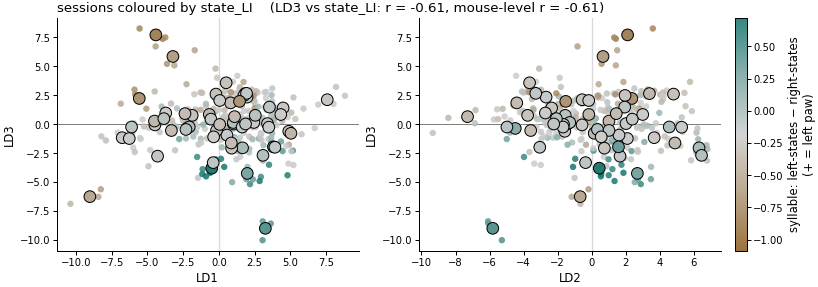

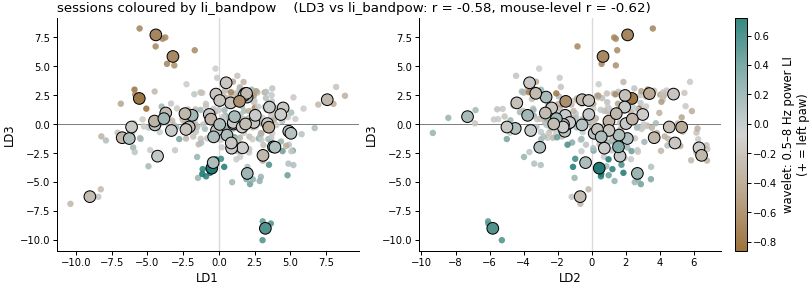

In [ ]:
def laterality_scatter(ax, xcol, ycol, cvar, data=data, mouse_means=True,
                       cmap=None, label=None):
    """One dot per session on (xcol, ycol), coloured by cvar, centred on cvar's median."""
    d = data[[xcol, ycol, cvar, 'mouse_name']].dropna()
    import matplotlib.colors as mcolors
    v = d[cvar].to_numpy(float)
    c = float(np.median(v))
    half = max(abs(v - c).max(), 1e-9)
    norm = mcolors.TwoSlopeNorm(vmin=c - half, vcenter=c, vmax=c + half)
    cmap = ps.DIVERGING_CMAP if cmap is None else cmap
    sc = ax.scatter(d[xcol], d[ycol], c=v, cmap=cmap, norm=norm,
                    s=(plt.rcParams['lines.markersize'] * 1.1) ** 2,
                    alpha=0.85, edgecolors='none', zorder=2)
    if mouse_means:
        mm = d.groupby('mouse_name').mean(numeric_only=True)
        ax.scatter(mm[xcol], mm[ycol], c=mm[cvar], cmap=cmap, norm=norm,
                   s=(plt.rcParams['lines.markersize'] * 2.0) ** 2,
                   edgecolors='k', linewidths=0.6, zorder=3)
    ps.zero_line(ax)
    ax.axvline(0, color='0.85', lw=0.8, zorder=0)
    ax.set(xlabel=xcol, ylabel=ycol)
    return sc, norm


for cvar in ['state_LI', 'li_bandpow']:
    fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['single'][0] * 2.2,
                                            ps.SIZES[ps.MODE]['single'][1] * 1.05))
    for ax, x in zip(axes, ['LD1', 'LD2']):
        sc, _ = laterality_scatter(ax, x, 'LD3', cvar)
        r, p = stats.pearsonr(data['LD3'], data[cvar])
    fig.colorbar(sc, ax=axes, label=f'{MEASURES[cvar]}\n(+ = left paw)',
                 fraction=0.025, pad=0.02)
    axes[0].set_title(f'sessions coloured by {cvar}    '
                      f'(LD3 vs {cvar}: r = {r:+.2f}, mouse-level '
                      f'r = {stats.pearsonr(mouse.LD3, mouse[cvar])[0]:+.2f})',
                      loc='left')
    if SAVE_FIGS:
        ps.savefig(fig, f'ld_scatter_{cvar}', subdir='laterality')
    plt.show()

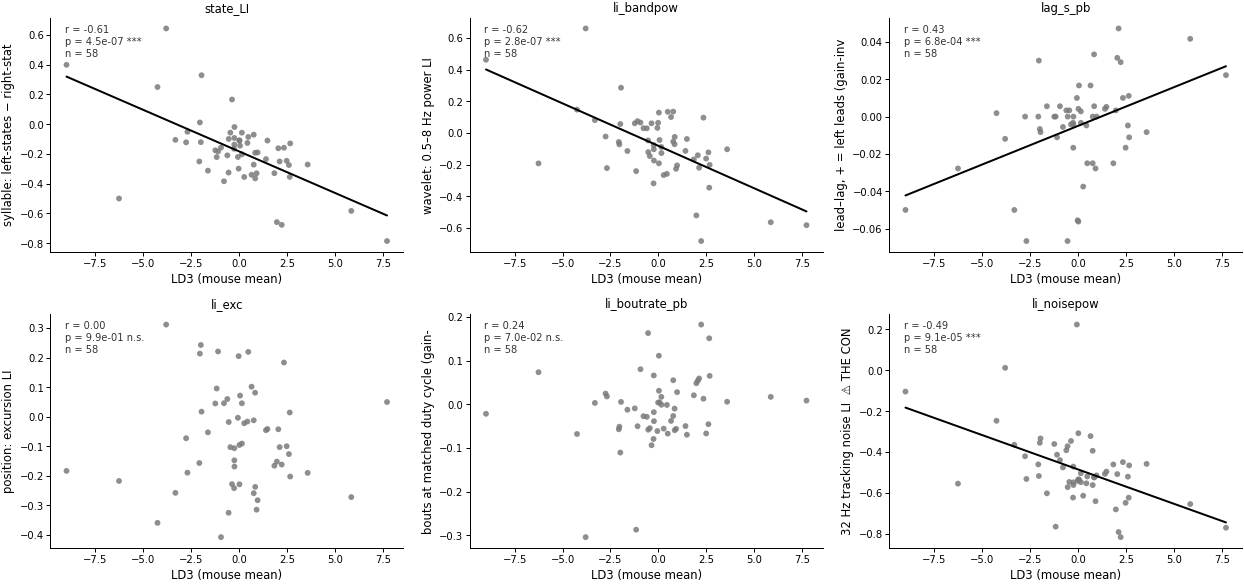

In [ ]:
"""The direct panels: LD3 against each laterality measure, one point per mouse."""
show = ['state_LI', 'li_bandpow', 'lag_s_pb', 'li_exc', 'li_boutrate_pb', 'li_noisepow']
fig, axes = plt.subplots(2, 3, figsize=(ps.SIZES[ps.MODE]['single'][0] * 3.1,
                                        ps.SIZES[ps.MODE]['single'][1] * 2.1))
for ax, meas in zip(axes.ravel(), show):
    ps.corr_panel(ax, mouse.LD3, mouse[meas], color=ps.NEUTRAL,
                  xlabel='LD3 (mouse mean)', ylabel=MEASURES[meas][:34])
    ax.set_title(meas, fontsize=plt.rcParams['font.size'])
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'ld3_vs_laterality_measures', subdir='laterality')
plt.show()

## 8. Does the motor asymmetry reach the choice?

LD3 is a **movement** axis: high LD3 = more right-paw movement, and that survives the
camera-noise partial and lab-centring (sections 5–6). Whether the asymmetry reaches the
**decision** is a separate question, and the psychometric curve is where it would show.

Two things to look for along LD3:

* a **shift of the whole curve** — a mouse that moves one forepaw more reporting that side
  more often. This is the leak a motor axis would produce, and it is directional: high LD3
  is more right paw, so it predicts more right choices — P(right) up, the 50% point down.
* a change in the **block shift**, the gap between the p(left) = 0.2 and 0.8 curves. That
  gap is the prior, not the motor act; if it moved along LD3 the axis would be carrying
  something about how the mouse decides and not only about how it moves.

A flat answer is a real answer here. It is what licenses calling LD3 a paw axis rather than
a bias axis, and it is the thing a reviewer will ask for.

**The trap this rests on, handled in `lf.trial_features()`.** The `choice` strings in every
trial table in this repo are *mirrored*: `1_segmentation/functions.py` writes `'right'` for
ALF `trials.choice == +1`, and +1 is the counter-clockwise turn — the report of a stimulus
on the **left**. The data says so twice: on correct trials `choice == 'right'` pairs with
`contrastRight − contrastLeft < 0` in 100% of trials, and in the p(left) = 0.2 block 80% of
the stimuli fall on the side the strings call `'right'`. A curve drawn straight off those
labels is its own mirror image and looks entirely normal while it is — which for a
laterality question inverts the result. Everything below is oriented on `block`
(= `probabilityLeft`, not mirrored) instead, so **signed contrast > 0 = stimulus on the
right**, y = P(choice = right), and the 0.2 block sits above the 0.8 block.

**What this section needs to run.** Only the embedding and a trial table, so it works
when the paw-wavelet tree behind sections 1–7 is not on the machine: run the config and
imports cells, the cell that loads `lda`, the cell that defines `corr_report` / `fdr`
(section 5), and then the three cells below.

In [ ]:
"""
TRIAL BEHAVIOUR FOR THE LDA'S OWN SESSIONS
==========================================
lf.trial_features() re-derives the signed contrast rather than reading it, and fixes
left from right using `block` (= probabilityLeft, straight out of ALF) rather than the
`choice` strings, which are MIRRORED in every trial table in this repo -- its docstring
carries the two independent proofs. A mirrored curve looks perfectly reasonable, and
for a laterality question the sign is the entire result, so the orientation check it
prints is worth reading on every run.

Convention out of it:  signed_contrast > 0 = stimulus on the RIGHT,
                       y = P(choice = right),
                       block = p(left), so 0.2 sits above 0.8.
"""
LD_AXIS = 'LD3'           # change here and re-run from this cell to screen another axis
MIN_BLOCK_TRIALS = 40     # per block, for a session/mouse to give a block-shift number
MIN_POINT_TRIALS = 5      # per (contrast, block) cell, for it to be a point on a curve

trials = lf.trial_features(sessions=lda.index)
for col in ('mouse_name', 'lab', LD_AXIS):
    trials[col] = lda[col].reindex(trials.session).to_numpy()

cov = trials.groupby('session').size()
print(f'\n{len(cov)} of {len(lda)} LDA sessions have trials '
      f'({len(lda.index.difference(cov.index))} missing), '
      f'{trials.mouse_name.nunique()} of {lda.mouse_name.nunique()} mice')
print('trials per session:', cov.describe()[['min', '50%', 'max']].astype(int).to_dict())

n_per_block = (trials.pivot_table(index='session', columns='block',
                                  values='choice_right', aggfunc='size')
               .reindex(columns=[0.2, 0.5, 0.8]))
both = (n_per_block[0.2] >= MIN_BLOCK_TRIALS) & (n_per_block[0.8] >= MIN_BLOCK_TRIALS)
print(f'sessions with >= {MIN_BLOCK_TRIALS} trials in BOTH biased blocks: {int(both.sum())}'
      f'  ({int((~both).sum())} contribute to the curves but not to a block shift)')

trials from session_trial_meta_10-07-2026: 154375 rows, 244 sessions
  orientation: 0.203 of p(left)=0.2 stimuli are on the side this file's `choice` strings call 'right' (0.8 block: 0.807)
  -> the labels are MIRRORED and have been flipped; this file's 'right' is the screen's LEFT
  kept 151677 trials (2698 dropped: no-go, missing fields, sessions outside the cohort, 0 sessions under 100 trials)
  242 sessions, block counts {0.2: 63773, 0.5: 21768, 0.8: 66136}
  sanity, P(choice = right) at 0% contrast per block: 0.2 -> 0.698, 0.5 -> 0.527, 0.8 -> 0.367   (must FALL as p(left) rises)

242 of 269 LDA sessions have trials (27 missing), 56 of 58 mice
trials per session: {'min': 385, '50%': 581, 'max': 1524}
sessions with >= 40 trials in BOTH biased blocks: 242  (0 contribute to the curves but not to a block shift)


In [10]:
"""
PSYCHOMETRIC CURVES ALONG LD3
=============================
Panels are quantile bins of LD3, left to right = more LEFT-paw to more RIGHT-paw
(section 6: high LD3 = more right-paw movement). One curve per block inside each panel.

BIN_ON = 'mouse' bins on the MOUSE MEAN of LD3, so a mouse lands in exactly one panel
and cannot appear in two; the markers are then the mean over mice in that bin and the
error bars their SEM across mice -- the unit that is not pseudo-replicated, as
everywhere else in this notebook. BIN_ON = 'session' bins the 269 sessions directly,
which spreads further along the axis at the price of one mouse straddling panels.
"""
from scipy.optimize import curve_fit

N_LD_BINS = 3
BIN_ON = 'mouse'          # 'mouse' or 'session'
BLOCKS = [0.2, 0.5, 0.8]


def psychometric(x, mu, sigma, gamma, lam):
    """4-parameter logistic in % contrast.
      mu     the 50% point. POSITIVE = the mouse needs rightward evidence to call it
             right, i.e. it is LEFT-biased.
      sigma  inverse slope; gamma / lam the lapse rates at -100% and +100%.
    """
    return gamma + (1 - gamma - lam) / (1 + np.exp(-(x - mu) / sigma))


PSYCH_P0 = [0.0, 15.0, 0.05, 0.05]
PSYCH_BOUNDS = ([-100.0, 1.0, 0.0, 0.0], [100.0, 200.0, 0.45, 0.45])


def fit_psychometric(x, y):
    """Least squares through (x, y) points; None if it will not converge or there are
    too few contrasts to constrain four parameters. Fitted to the per-MOUSE means, not
    to the raw trials, so every mouse weighs the same and the line goes through the
    markers the panel actually shows."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 4 or len(np.unique(x[ok])) < 4:
        return None
    try:
        popt, _ = curve_fit(psychometric, x[ok], y[ok], p0=PSYCH_P0,
                            bounds=PSYCH_BOUNDS, maxfev=20000)
        return popt
    except Exception:
        return None


# --- bin the LD axis on units, never on trials: qcut over trials would balance TRIALS
unit = 'mouse_name' if BIN_ON == 'mouse' else 'session'
unit_ld = (lda.groupby('mouse_name')[LD_AXIS].mean() if BIN_ON == 'mouse'
           else lda[LD_AXIS])
unit_ld = unit_ld[unit_ld.index.isin(trials[unit].unique())]
qbin = pd.qcut(unit_ld, N_LD_BINS)
edges = qbin.cat.categories
trials['ld_bin'] = trials[unit].map(pd.Series(qbin.cat.codes, index=qbin.index)).replace(-1, np.nan)

# per (bin, block, contrast) one value PER MOUSE first, then across mice
per_unit = (trials.dropna(subset=['ld_bin'])
            .groupby(['ld_bin', 'block', 'signed_contrast', 'mouse_name'])
            .agg(p_right=('choice_right', 'mean'), n=('choice_right', 'size'))
            .reset_index())
per_unit = per_unit[per_unit.n >= MIN_POINT_TRIALS]
agg = (per_unit.groupby(['ld_bin', 'block', 'signed_contrast'])
       .p_right.agg(['mean', 'sem', 'size']).reset_index())

fig, axes = plt.subplots(1, N_LD_BINS, sharey=True, sharex=True,
                         figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.15 * N_LD_BINS,
                                  ps.SIZES[ps.MODE]['single'][1] * 1.15))
axes = np.atleast_1d(axes)
xx = np.linspace(-100, 100, 300)
fits = []
for b, ax in enumerate(axes):
    in_bin = trials.ld_bin == b
    for block in BLOCKS:
        pts = agg[(agg.ld_bin == b) & (agg.block == block)].sort_values('signed_contrast')
        raw = per_unit[(per_unit.ld_bin == b) & (per_unit.block == block)]
        if pts.empty:
            continue
        ax.errorbar(pts.signed_contrast, pts['mean'], yerr=pts['sem'], fmt='o',
                    color=ps.BLOCK[block], ms=plt.rcParams['lines.markersize'] * 0.85,
                    lw=0, elinewidth=0.9, capsize=1.5, zorder=3,
                    label=ps.BLOCK_LABEL[block] if b == N_LD_BINS - 1 else None)
        popt = fit_psychometric(raw.signed_contrast, raw.p_right)
        if popt is not None:
            ax.plot(xx, psychometric(xx, *popt), color=ps.BLOCK[block], lw=1.2, zorder=2)
        fits.append(dict(ld_bin=b, block=block,
                         mu=np.nan if popt is None else popt[0],
                         sigma=np.nan if popt is None else popt[1],
                         lapse=np.nan if popt is None else 0.5 * (popt[2] + popt[3]),
                         n_mice=raw.mouse_name.nunique(),
                         n_trials=int((in_bin & (trials.block == block)).sum())))
    ax.axhline(0.5, color='0.85', lw=0.8, zorder=0)
    ax.axvline(0, color='0.85', lw=0.8, zorder=0)
    n_m = int(trials.loc[in_bin, 'mouse_name'].nunique())
    n_s = int(trials.loc[in_bin, 'session'].nunique())
    ax.set(xlabel='signed contrast (%)\n+ = stimulus on the right',
           title=f'{LD_AXIS} {edges[b].left:+.1f} to {edges[b].right:+.1f}\n'
                 f'{n_m} mice, {n_s} sessions, {int(in_bin.sum()):,} trials',
           ylim=(0, 1), xlim=(-105, 105))
axes[0].set_ylabel('P(choice = right)')
axes[-1].legend(frameon=False, loc='upper left',
                fontsize=plt.rcParams['font.size'] * 0.8)
axes[0].text(0.03, 0.97, 'more LEFT paw', transform=axes[0].transAxes,
             va='top', ha='left', color='0.35',
             fontsize=plt.rcParams['font.size'] * 0.8)
axes[-1].text(0.97, 0.03, 'more RIGHT paw', transform=axes[-1].transAxes,
              va='bottom', ha='right', color='0.35',
              fontsize=plt.rcParams['font.size'] * 0.8)
fig.suptitle(f'Psychometric curves along {LD_AXIS} '
             f'({N_LD_BINS} quantile bins of {"mouse-mean " if BIN_ON == "mouse" else ""}'
             f'{LD_AXIS}; points = mean +- SEM over mice)', y=1.02)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, f'{LD_AXIS.lower()}_psychometric_blocks', subdir='laterality')
plt.show()

fits = pd.DataFrame(fits)
print('fitted parameters per panel (mu = 50% point in %, + = LEFT-biased):')
display(fits.set_index(['ld_bin', 'block']).round(3))

NameError: name 'LD_AXIS' is not defined

In [11]:
"""
DOES ANY OF IT ACTUALLY MOVE WITH LD3?
======================================
The panels above are three bins; this is the same question without throwing the axis
away. One psychometric summary per MOUSE, correlated with that mouse's mean LD3, with
the notebook's permutation p and an FDR across the table, plus the lab-centred r --
LD3 is the one leading axis a lab label does not explain (section 6, control 3), but
block behaviour differs between labs, so the control is cheap and worth having.

WHAT A LEAK WOULD LOOK LIKE. High LD3 = more right-paw movement. If that asymmetry
reached the decision, the mouse would report right more often: p_right UP and the 50%
point mu DOWN (mu is positive for a LEFT-biased mouse). Those two are the directed
predictions; the rest of the table is the two-sided question of whether LD3 touches
sensitivity, lapses or the prior at all.

SIGN NOTE. `block shift` here is P(right | p(left) = 0.2) - P(right | p(left) = 0.8),
POSITIVE for a mouse that uses the block. 4_mice/LDA_behavior.ipynb defines its `bias`
the other way round and off the mirrored choice labels, so the two are not the same
number and must not be compared.
"""
MU_MAX = 50.0            # a 50% point beyond this is a failed fit, not a biased mouse

rows, n_bad = [], 0
for m, g in trials.groupby('mouse_name'):
    r = {'mouse_name': m, 'n_sessions': g.session.nunique(), 'n_trials': len(g),
         'p_right': g.choice_right.mean()}

    z = g[g.contrast == 0].groupby('block').choice_right.agg(['mean', 'size'])
    if {0.2, 0.8} <= set(z.index) and z.loc[[0.2, 0.8], 'size'].min() >= MIN_POINT_TRIALS:
        r['shift0'] = float(z.loc[0.2, 'mean'] - z.loc[0.8, 'mean'])

    # the same shift read off every contrast the two blocks share, which is the same
    # quantity measured on ~9x the trials and correspondingly less noisy
    mean_tab = g.pivot_table(index='signed_contrast', columns='block',
                             values='choice_right', aggfunc='mean')
    n_tab = g.pivot_table(index='signed_contrast', columns='block',
                          values='choice_right', aggfunc='size')
    if {0.2, 0.8} <= set(mean_tab.columns):
        ok = (n_tab[0.2] >= MIN_POINT_TRIALS) & (n_tab[0.8] >= MIN_POINT_TRIALS)
        if ok.sum() >= 3:
            r['shift_all'] = float((mean_tab.loc[ok, 0.2] - mean_tab.loc[ok, 0.8]).mean())

    for block, tag in [(0.5, 'unb'), (0.2, 'b02'), (0.8, 'b08')]:
        gb = g[g.block == block]
        if len(gb) < MIN_BLOCK_TRIALS:
            continue
        pc = gb.groupby('signed_contrast').choice_right.agg(['mean', 'size'])
        pc = pc[pc['size'] >= MIN_POINT_TRIALS]
        popt = fit_psychometric(pc.index.to_numpy(), pc['mean'].to_numpy())
        # A 50% point past +-MU_MAX is a fit that ran away, not a mouse: on 5 contrasts
        # and a few hundred trials curve_fit will happily put mu at 80% to buy a little
        # residual. Dropped rather than kept, because one of those moves a correlation
        # across 58 mice on its own -- the shift0 / shift_all columns need no fit at all
        # and are the ones to lean on.
        if popt is None or abs(popt[0]) > MU_MAX:
            n_bad += popt is not None
            continue
        r[f'mu_{tag}'], r[f'slope_{tag}'] = popt[0], 1.0 / popt[1]
        r[f'lapse_{tag}'] = 0.5 * (popt[2] + popt[3])
    rows.append(r)

psych_mouse = pd.DataFrame(rows).set_index('mouse_name')
psych_mouse['mu_shift'] = psych_mouse.get('mu_b08') - psych_mouse.get('mu_b02')
# The mouse-level LD and lab, taken from `lda` rather than from `mouse` (section 5).
# The two are the same numbers -- `data` is a left join onto `lda`, so the mouse means
# match -- but going through `lda` keeps this section runnable when the paw-wavelet and
# state-profile files behind sections 1-7 are not on the machine.
psych_mouse[LD_AXIS] = lda.groupby('mouse_name')[LD_AXIS].mean().reindex(psych_mouse.index)
psych_mouse['lab'] = lda.groupby('mouse_name')['lab'].first().reindex(psych_mouse.index)
print(f'{len(psych_mouse)} mice; {n_bad} per-mouse block fits dropped for |mu| > {MU_MAX:.0f}%')
print('non-missing per measure:')
print(psych_mouse.notna().sum().to_string())

PSYCH_MEASURES = {
    'p_right':   'overall P(choice = right)',
    'mu_unb':    'unbiased block: 50% point (%, + = left-biased)',
    'slope_unb': 'unbiased block: slope (1/sigma)',
    'lapse_unb': 'unbiased block: mean lapse',
    'shift0':    'block shift at 0% contrast',
    'shift_all': 'block shift, over all shared contrasts',
    'mu_shift':  'block shift in the 50% point (%)',
}
# the directed predictions a motor leak makes; everything else is two-sided
EXPECTED = {'p_right': '+', 'mu_unb': '-'}

cen = psych_mouse.copy()
for col in [LD_AXIS] + list(PSYCH_MEASURES):
    cen[col] = cen.groupby('lab')[col].transform(lambda s: s - s.mean())

prows = []
for meas, label in PSYCH_MEASURES.items():
    res = corr_report(psych_mouse[LD_AXIS], psych_mouse[meas], n_perm=N_PERM)
    ok = np.isfinite(cen[LD_AXIS]) & np.isfinite(cen[meas])
    r_lab = (stats.pearsonr(cen[LD_AXIS][ok], cen[meas][ok])[0] if ok.sum() > 5 else np.nan)
    prows.append(dict(measure=meas, label=label, predicted=EXPECTED.get(meas, ''),
                      r_lab_centred=r_lab, **res))
psych_screen = pd.DataFrame(prows).set_index('measure')
psych_screen['q_fdr'] = fdr(psych_screen.p_perm)

print(f'\n{LD_AXIS} vs each psychometric summary, one point per mouse '
      f'(n = {len(psych_mouse)}), FDR over the {len(psych_screen)} rows\n')
print(f'{"measure":46s}{"pred":>5s}{"n":>5s}{"r":>9s}{"p_perm":>9s}{"q":>8s}{"r|lab":>9s}')
for meas, row in psych_screen.iterrows():
    print(f'{row.label[:46]:46s}{row.predicted:>5s}{int(row.n):5d}{row.r:+9.3f}'
          f'{row.p_perm:9.4f}{row.q_fdr:8.3f}{row.r_lab_centred:+9.3f}')

show = [m for m in PSYCH_MEASURES if psych_mouse[m].notna().sum() > 10]
ncol = 3
nrow = int(np.ceil(len(show) / ncol))
fig, axes = plt.subplots(nrow, ncol,
                         figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.05 * ncol,
                                  ps.SIZES[ps.MODE]['single'][1] * 1.05 * nrow))
for ax, meas in zip(np.atleast_1d(axes).ravel(), show):
    ps.corr_panel(ax, psych_mouse[LD_AXIS], psych_mouse[meas], color=ps.NEUTRAL,
                  xlabel=f'{LD_AXIS} (mouse mean)', ylabel=PSYCH_MEASURES[meas][:34])
    ax.set_title(meas, fontsize=plt.rcParams['font.size'])
for ax in np.atleast_1d(axes).ravel()[len(show):]:
    ax.axis('off')
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, f'{LD_AXIS.lower()}_vs_psychometrics', subdir='laterality')
plt.show()

hit = psych_screen[psych_screen.q_fdr < ALPHA]
if len(hit) == 0:
    print(f'\nNothing in the table survives FDR. {LD_AXIS} separates mice by which forepaw '
          f'they move\nwithout separating them by how they choose -- a motor axis that '
          f'leaves the decision alone.\nThe directed predictions are the ones to quote: '
          + ', '.join(f'{m} r = {psych_screen.loc[m, "r"]:+.3f} '
                      f'(predicted {EXPECTED[m]}, p_perm = {psych_screen.loc[m, "p_perm"]:.3f})'
                      for m in EXPECTED if m in psych_screen.index))
else:
    print(f'\nSurvives FDR at q < {ALPHA}: '
          + '; '.join(f'{m} r = {row.r:+.3f} (q = {row.q_fdr:.3f}, lab-centred '
                      f'{row.r_lab_centred:+.3f})' for m, row in hit.iterrows()))
    print('Check the sign against the prediction before reading anything into it, and '
          'check\nthe lab-centred column: a relation that only exists across labs is a rig '
          'effect.')

NameError: name 'trials' is not defined

## 9. Reaction times: biased by the block, by the choice, or by neither?

Section 8 asked whether the paw asymmetry reaches *which* side the mouse picks. This one
asks whether it reaches *how fast* the mouse gets there — which for a motor axis is the
more likely place to find it. `reaction` is the latency from the go cue to the first wheel
movement, and that movement is made with the forepaws.

Three questions, in increasing order of how much they are about LD3:

1. **Is RT biased by the block?** Matched on |contrast|: is a mouse quicker when the
   stimulus lands on the side the block has made likely?
2. **Is RT biased by the side chosen?** Matched on block and contrast: is it quicker to
   the left or to the right — across the cohort, and, the question that matters here,
   *within* each mouse?
3. **Does either move with LD3?**

A null in 3 is only worth anything if the measure in 2 is stable enough to correlate with
anything at all, so the **split-half over each mouse's own sessions** is reported next to
every measure. That is the difference between "LD3 does not explain this" and "nothing
could explain this", and the two are not distinguishable from a p-value.

One thing to keep in view while reading the left/right numbers: the two forepaws are
measured by two different cameras, but a reaction time is not — it comes from the wheel,
one device, no laterality artefact. So unlike every index in sections 1–7, the **population
mean** of an RT asymmetry is interpretable here, not just its spread.

In [12]:
"""
CHRONOMETRIC CURVES ALONG LD3
=============================
The same panels as the psychometric figure -- same bins, same blocks -- with reaction
time on y. `reaction` is firstMovement_times - goCue_times: the latency to the first
wheel movement, which is a forelimb act, and so the place a paw asymmetry could show
even when the choice itself is untouched.

THE TRIALS THIS THROWS AWAY. About 13% of trials have reaction <= 0 -- the mouse was
already moving when the go cue arrived. Those are not reaction times, a log cannot take
them, and they are not a random 13%: a mouse that moves early does it repeatedly. They
are dropped together with the ~2% over 10 s, and the count is printed, because the
alternative (a median over a mixture) hides the same problem rather than fixing it.
"""
import matplotlib.ticker as mticker

RT_WINDOW = (0.02, 10.0)      # seconds; outside it the value is not a reaction time
RT_MIN_CELL = 10              # trials per (mouse, condition) cell before it gives a value

assert 'reaction' in trials, 'this trial table carries no reaction times'
rt = trials.copy()
rt['logrt'] = np.log(rt.reaction.where(rt.reaction.between(*RT_WINDOW)))
n_lo = int((rt.reaction <= RT_WINDOW[0]).sum())
n_hi = int((rt.reaction >= RT_WINDOW[1]).sum())
print(f'{len(rt):,} trials -> {int(rt.logrt.notna().sum()):,} usable reaction times '
      f'({n_lo:,} at or before the go cue, {n_hi:,} over {RT_WINDOW[1]:.0f} s, '
      f'{int(rt.reaction.isna().sum()):,} missing)')
rt = rt[np.isfinite(rt.logrt)]
print('median RT per block (ms): '
      + ', '.join(f'{b} -> {1000 * np.exp(v):.0f}'
                  for b, v in rt.groupby('block').logrt.median().items()))

# one median per MOUSE per cell first, then across mice -- as in the psychometric figure
per_unit_rt = (rt.dropna(subset=['ld_bin'])
               .groupby(['ld_bin', 'block', 'signed_contrast', 'mouse_name'])
               .agg(logrt=('logrt', 'median'), n=('logrt', 'size')).reset_index())
per_unit_rt = per_unit_rt[per_unit_rt.n >= MIN_POINT_TRIALS]
agg_rt = (per_unit_rt.groupby(['ld_bin', 'block', 'signed_contrast'])
          .logrt.agg(['mean', 'sem', 'size']).reset_index())

fig, axes = plt.subplots(1, N_LD_BINS, sharey=True, sharex=True,
                         figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.15 * N_LD_BINS,
                                  ps.SIZES[ps.MODE]['single'][1] * 1.15))
axes = np.atleast_1d(axes)
for b, ax in enumerate(axes):
    for block in BLOCKS:
        pts = agg_rt[(agg_rt.ld_bin == b) & (agg_rt.block == block)].sort_values('signed_contrast')
        if pts.empty:
            continue
        # back to seconds for the axis; the mean and its SEM are taken in log, where the
        # distribution is roughly symmetric, so the interval is multiplicative
        m = np.exp(pts['mean'])
        ax.errorbar(pts.signed_contrast, m,
                    yerr=[m - np.exp(pts['mean'] - pts['sem']),
                          np.exp(pts['mean'] + pts['sem']) - m],
                    fmt='o-', color=ps.BLOCK[block], lw=1.1,
                    ms=plt.rcParams['lines.markersize'] * 0.85, elinewidth=0.9, capsize=1.5,
                    label=ps.BLOCK_LABEL[block] if b == N_LD_BINS - 1 else None)
    ax.axvline(0, color='0.85', lw=0.8, zorder=0)
    # log y, because a reaction time is multiplicative, but with plain second labels --
    # matplotlib's default 4x10^-1 ticks are unreadable at this range
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mticker.FixedLocator([0.1, 0.15, 0.2, 0.3, 0.4, 0.6]))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    in_bin = trials.ld_bin == b
    ax.set(xlabel='signed contrast (%)\n+ = stimulus on the right',
           title=f'{LD_AXIS} {edges[b].left:+.1f} to {edges[b].right:+.1f}\n'
                 f'{int(trials.loc[in_bin, "mouse_name"].nunique())} mice, '
                 f'{int(trials.loc[in_bin, "session"].nunique())} sessions',
           xlim=(-105, 105))
axes[0].set_ylabel('reaction time (s)\ngeometric mean over mice')
axes[-1].legend(frameon=False, loc='upper right',
                fontsize=plt.rcParams['font.size'] * 0.8)
fig.suptitle(f'Chronometric curves along {LD_AXIS}', y=1.02)
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, f'{LD_AXIS.lower()}_chronometric_blocks', subdir='laterality')
plt.show()

NameError: name 'trials' is not defined

In [13]:
"""
IS REACTION TIME BIASED BY THE BLOCK, OR BY THE SIDE CHOSEN?
============================================================
Both questions are asked as MATCHED differences: the contrast (and for the choice
question the block as well) is held fixed inside each cell, the two sides are compared
within that cell, and the cells are then averaged. Without the matching a left/right RT
difference is mostly a report of which side the stimuli happened to be on.

  rt_block   log RT on the UNLIKELY side minus the LIKELY side, matched on |contrast|,
             biased blocks only. Positive = the prior speeds the mouse up.
  rt_lr0     log RT for LEFT choices minus RIGHT choices at 0% CONTRAST, matched on
             block. The cleanest left/right comparison there is: with no stimulus the
             choice is the mouse's own, and reward is random, so neither side is the
             correct one. (Errors are slow -- +0.55 log units in this cohort -- so any
             comparison that lets correctness differ between the sides is measuring
             that instead.)
  rt_lr      the same difference over every contrast, matched on block x signed
             contrast. More trials, at the price of mixing correct with error trials in
             a way that only cancels because the contrasts are symmetric.

AND THEN THE QUESTION THAT DECIDES WHETHER ANY OF IT IS A TRAIT: split-half across a
mouse's OWN sessions. A measure whose halves do not agree cannot correlate with LD3 or
with anything else, so an r near zero for it means nothing. rt_median is the positive
control -- a mouse's overall speed is obviously stable, and if the split-half machinery
did not show that, the machinery would be what is broken.
"""
RT_MEASURES = {
    'rt_block':  'block effect: unlikely - likely side (log RT)',
    'rt_lr0':    'left - right (log RT), 0% contrast only',
    'rt_lr':     'left - right (log RT), all contrasts matched',
    'rt_median': 'median log RT  (positive control, a level not a contrast)',
}


def _cell_diff(df, keys, split, lo, hi, min_n=RT_MIN_CELL):
    """Mean log RT for `lo` minus `hi`, within each cell of `keys`, averaged over the
    cells where BOTH sides carry at least `min_n` trials."""
    c = df.groupby(keys + [split]).logrt.agg(['mean', 'size']).unstack(split)
    if ('size', lo) not in c or ('size', hi) not in c:
        return pd.Series(dtype=float)
    ok = (c[('size', lo)] >= min_n) & (c[('size', hi)] >= min_n)
    return (c[('mean', lo)] - c[('mean', hi)])[ok].dropna()


def rt_measures(g):
    """The four summaries for one mouse (or for one half of its sessions)."""
    b = g[(g.block != 0.5) & (g.signed_contrast != 0)].copy()
    b['likely'] = (b.signed_contrast > 0) == (b.block == 0.2)
    d_block = _cell_diff(b, ['contrast'], 'likely', False, True)
    d_lr0 = _cell_diff(g[g.contrast == 0], ['block'], 'choice_right', 0.0, 1.0)
    d_lr = _cell_diff(g, ['block', 'signed_contrast'], 'choice_right', 0.0, 1.0)
    return {'rt_block': d_block.mean() if len(d_block) else np.nan,
            'rt_lr0': d_lr0.mean() if len(d_lr0) else np.nan,
            'rt_lr': d_lr.mean() if len(d_lr) else np.nan,
            'rt_median': g.logrt.median()}


rt_mouse = (pd.DataFrame({m: rt_measures(g) for m, g in rt.groupby('mouse_name')})
            .T.astype(float))
rt_mouse[LD_AXIS] = lda.groupby('mouse_name')[LD_AXIS].mean().reindex(rt_mouse.index)
rt_mouse['lab'] = lda.groupby('mouse_name')['lab'].first().reindex(rt_mouse.index)

print('IS THE COHORT BIASED? one value per mouse, tested against zero\n')
print(f'{"measure":52s}{"n":>4s}{"mean":>9s}{"sd":>8s}{"t p":>9s}{"wilcox":>9s}{"same sign":>11s}')
coh = []
for meas, label in RT_MEASURES.items():
    s = rt_mouse[meas].dropna().astype(float)
    if meas == 'rt_median':                     # a level: testing it against 0 is silly
        print(f'{label[:52]:52s}{len(s):4d}{s.mean():+9.3f}{s.std():8.3f}'
              f'{"--":>9s}{"--":>9s}{"--":>11s}   median RT = {1000*np.exp(s.mean()):.0f} ms')
        coh.append(dict(measure=meas, mean=s.mean(), p_t=np.nan, p_wil=np.nan))
        continue
    p_t = stats.ttest_1samp(s, 0).pvalue
    p_w = stats.wilcoxon(s).pvalue
    print(f'{label[:52]:52s}{len(s):4d}{s.mean():+9.3f}{s.std():8.3f}{p_t:9.4f}{p_w:9.4f}'
          f'{int((s > 0).sum()):7d}/{len(s):<3d}')
    coh.append(dict(measure=meas, mean=s.mean(), p_t=p_t, p_wil=p_w))
coh = pd.DataFrame(coh).set_index('measure')

print('\nIS IT A TRAIT? split-half over each mouse\'s own sessions (odd vs even)\n')
print(f'{"measure":52s}{"n":>4s}{"split-half r":>14s}{"p":>9s}{"full-length":>13s}')
rel = {}
for meas in RT_MEASURES:
    h = {}
    for m, g in rt.groupby('mouse_name'):
        s = sorted(g.session.unique())
        if len(s) < 2:
            continue
        h[m] = (rt_measures(g[g.session.isin(s[0::2])])[meas],
                rt_measures(g[g.session.isin(s[1::2])])[meas])
    a = pd.DataFrame(h, index=['h1', 'h2']).T.astype(float).dropna()
    if len(a) < 5:
        continue
    r, p = stats.pearsonr(a.h1, a.h2)
    sb = 2 * r / (1 + r)          # Spearman-Brown: half-length r -> full-length r
    rel[meas] = sb
    print(f'{RT_MEASURES[meas][:52]:52s}{len(a):4d}{r:+14.3f}{p:9.4f}{sb:+13.3f}')
print('\n"full-length" is the Spearman-Brown correction: the reliability of the measure as\n'
      'actually computed, on all of a mouse\'s sessions. It caps any correlation the next\n'
      'cell can find -- a measure at 0.2 cannot correlate with LD3 no matter what is true.')

NameError: name 'rt' is not defined

In [14]:
"""
DO THE REACTION-TIME ASYMMETRIES MOVE WITH LD3?
===============================================
The directed prediction, again: high LD3 = more RIGHT-paw movement, so a motor leak
would make the mouse quicker to the right, i.e. left minus right POSITIVE. rt_block has
no directional prediction -- LD3 is not a prior axis, and section 8 already found the
block shift in choice untouched.
"""
RT_EXPECTED = {'rt_lr0': '+', 'rt_lr': '+'}

cen_rt = rt_mouse.copy()
for col in [LD_AXIS] + list(RT_MEASURES):
    cen_rt[col] = cen_rt.groupby('lab')[col].transform(lambda s: s - s.mean())

rows = []
for meas, label in RT_MEASURES.items():
    res = corr_report(rt_mouse[LD_AXIS], rt_mouse[meas].astype(float), n_perm=N_PERM)
    ok = np.isfinite(cen_rt[LD_AXIS]) & np.isfinite(cen_rt[meas].astype(float))
    r_lab = (stats.pearsonr(cen_rt[LD_AXIS][ok], cen_rt[meas].astype(float)[ok])[0]
             if ok.sum() > 5 else np.nan)
    rows.append(dict(measure=meas, label=label, predicted=RT_EXPECTED.get(meas, ''),
                     reliability=rel.get(meas, np.nan), r_lab_centred=r_lab, **res))
rt_screen = pd.DataFrame(rows).set_index('measure')
rt_screen['q_fdr'] = fdr(rt_screen.p_perm)
# the most a correlation could be, given how noisy the measure itself is
rt_screen['ceiling'] = np.sqrt(rt_screen.reliability.clip(lower=0))

print(f'{LD_AXIS} vs each reaction-time summary, one point per mouse\n')
print(f'{"measure":52s}{"pred":>5s}{"n":>4s}{"r":>8s}{"p_perm":>9s}{"q":>7s}'
      f'{"r|lab":>8s}{"ceiling":>9s}')
for meas, row in rt_screen.iterrows():
    print(f'{row.label[:52]:52s}{row.predicted:>5s}{int(row.n):4d}{row.r:+8.3f}'
          f'{row.p_perm:9.4f}{row.q_fdr:7.3f}{row.r_lab_centred:+8.3f}{row.ceiling:9.2f}')

show = list(RT_MEASURES)
fig, axes = plt.subplots(1, len(show),
                         figsize=(ps.SIZES[ps.MODE]['single'][0] * 1.05 * len(show),
                                  ps.SIZES[ps.MODE]['single'][1] * 1.05))
for ax, meas in zip(np.atleast_1d(axes).ravel(), show):
    ps.corr_panel(ax, rt_mouse[LD_AXIS], rt_mouse[meas].astype(float), color=ps.NEUTRAL,
                  xlabel=f'{LD_AXIS} (mouse mean)', ylabel=RT_MEASURES[meas][:34])
    if meas != 'rt_median':
        ps.zero_line(ax)
    ax.set_title(meas, fontsize=plt.rcParams['font.size'])
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, f'{LD_AXIS.lower()}_vs_reaction_times', subdir='laterality')
plt.show()

lr = rt_screen.loc['rt_lr0']
print(f'\nThe left/right RT asymmetry is a real individual trait -- reliability '
      f'{lr.reliability:.2f} across a\nmouse\'s own sessions, with a population mean of '
      f'{coh.loc["rt_lr0", "mean"]:+.3f} log units that is indistinguishable\nfrom zero '
      f'(p = {coh.loc["rt_lr0", "p_t"]:.2f}). Mice differ in which side they are quick to; '
      f'they do not agree on\nwhich side that is. The same shape as every laterality index '
      f'in this notebook.')
print(f'\nBut it is not {LD_AXIS}: r = {lr.r:+.3f} (p_perm = {lr.p_perm:.3f}, lab-centred '
      f'{lr.r_lab_centred:+.3f}), against a\nceiling of {lr.ceiling:.2f} that the measure\'s '
      f'own reliability allows. That is a null with teeth --\nthe measure is clean enough '
      f'that a relation of the size LD3 has with the paw indices\n(|r| ~ 0.6) would have '
      f'been impossible to miss.')

NameError: name 'rt_mouse' is not defined

## 10. Side bias at every contrast, not only at zero

Sections 8 and 9 both leaned on the 0% contrast trials — the psychometric 50% point and
the block shift are read there, and the cleanest left/right RT comparison lives there,
because with no stimulus neither side is the correct one. That is about 10% of the trials.

This section asks the same two questions of **every contrast**, which means confronting
what the 0% restriction was avoiding: above zero contrast one choice is correct and the
other is an error, errors are slow, and P(right) is driven by the stimulus. So a raw
left-minus-right difference at a fixed signed contrast measures error slowing and stimulus
side, not a bias.

The fix is to balance rather than to avoid — average over the two stimulus sides at matched
|contrast| and block for choice, and a stimulus × choice 2×2 within each cell for RT, which
puts one correct and one error cell on each side of the comparison. The RT effect is
estimated twice: on matched cells, as in section 9, and by a per-mouse regression over all
trials, because a matched cell needs a wrong-side choice to exist and at 100% contrast it
usually does not — **only 1% of the 100%-contrast cells have all four corners populated**
(72% at 6.25%, 51% at 12.5%, 20% at 25%). The regression keeps every trial and estimates
the same contrast with |contrast|, block and correctness carried as nuisance terms.

Reported per contrast as well as pooled, because where a bias lives is a fact about the
mouse: one that survives at 100% contrast is an asymmetry of **lapses**, one confined to
threshold is a shifted **criterion**.

In [15]:
"""
SIDE BIAS AT EVERY CONTRAST
===========================
Section 9 read the left/right RT asymmetry off the 0% contrast trials, because there
neither side is the correct one and the comparison is clean. That threw away 90% of the
data. Here the same two questions are asked of every contrast, which means dealing with
the reason they were avoided.

THE PROBLEM. At any contrast above zero, one choice is correct and the other is an
error, and errors are slow (+0.4 log units in this cohort, adjusted). So "left minus
right" at a fixed signed contrast is mostly a measure of error slowing wearing a
laterality costume. Same for choice: at a fixed signed contrast, P(right) is dominated
by the stimulus, not by any bias.

TWO FIXES, one per measure.

  choice   Average P(right) over the TWO STIMULUS SIDES at matched |contrast| and block,
           then subtract 0.5. The stimulus-driven half cancels and what is left is the
           mouse's own leaning. (It equals half the accuracy asymmetry between the two
           sides, which is the same statement said the other way round.)

  RT       A 2x2 within each (block, |contrast|) cell: stimulus side x choice side. The
           choice-L group is then {correct-left, error-left} and the choice-R group is
           {correct-right, error-right} -- one correct and one error cell each, so
           correctness is balanced out rather than avoided, and so is stimulus side.

Both are reported per |contrast|, because WHERE a bias lives matters: one that survives
at 100% contrast is an asymmetry of lapses, one that shows only near threshold is a
shifted criterion, and they are not the same thing about a mouse.
"""
CHOICE_MIN_CELL = 10          # trials per stimulus side in a (block, |contrast|) cell
CONTRASTS = sorted(trials.contrast.unique())

rt['stim_right'] = np.where(rt.contrast > 0, (rt.signed_contrast > 0).astype(float), np.nan)
trials['stim_right'] = np.where(trials.contrast > 0, (trials.signed_contrast > 0).astype(float), np.nan)


def side_by_contrast(g, grt):
    """Per (block, |contrast|) cell: the choice bias and the RT side effect, both with
    the stimulus balanced out. `g` is all the mouse's trials, `grt` the subset with a
    usable reaction time."""
    rows = []
    for (blk, con), h in g.groupby(['block', 'contrast']):
        rec = {'block': blk, 'contrast': con}
        hr = grt[(grt.block == blk) & (grt.contrast == con)]
        if con == 0:                       # no stimulus side to balance: P(right) is the bias
            if len(h) >= CHOICE_MIN_CELL:
                rec['choice_bias'] = h.choice_right.mean() - 0.5
            n = hr.groupby('choice_right').logrt.agg(['mean', 'size'])
            if len(n) == 2 and n['size'].min() >= RT_MIN_CELL:
                rec['rt_side'] = n['mean'].loc[0.0] - n['mean'].loc[1.0]
        else:
            p = h.groupby('stim_right').choice_right.agg(['mean', 'size'])
            if len(p) == 2 and p['size'].min() >= CHOICE_MIN_CELL:
                rec['choice_bias'] = p['mean'].mean() - 0.5
            q = hr.groupby(['stim_right', 'choice_right']).logrt.agg(['mean', 'size'])
            if len(q) == 4 and q['size'].min() >= RT_MIN_CELL:
                m = q['mean']
                rec['rt_side'] = (0.5 * (m[(0.0, 0.0)] + m[(1.0, 0.0)])
                                  - 0.5 * (m[(0.0, 1.0)] + m[(1.0, 1.0)]))
        rows.append(rec)
    # reindex, because a mouse whose every cell fails the trial minimum would otherwise
    # come back with the column missing rather than with the column full of NaN
    return pd.DataFrame(rows).reindex(columns=['block', 'contrast', 'choice_bias', 'rt_side'])


def rt_side_regression(grt):
    """The same RT contrast, estimated on every trial instead of on the cells that
    happen to be full. Effect-coded choice side and stimulus side with their
    interaction (which IS correctness, since correct <=> the two agree), and |contrast|
    and block absorbed as dummies. Returns (left - right, stimulus left - right,
    error slowing); the third is a check -- it has to come out positive and large."""
    ch = grt.choice_right.to_numpy(float) - 0.5
    st = np.where(np.isfinite(grt.stim_right), grt.stim_right.to_numpy(float) - 0.5, 0.0)
    X = [np.ones(len(grt)), ch, st, ch * st]
    X += [(grt.contrast == c).to_numpy(float) for c in sorted(grt.contrast.unique())[1:]]
    X += [(grt.block == b).to_numpy(float) for b in sorted(grt.block.unique())[1:]]
    X = np.column_stack(X)
    y = grt.logrt.to_numpy(float)
    if len(y) < 50 or np.linalg.matrix_rank(X) < X.shape[1]:
        return (np.nan,) * 3
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return -b[1], -b[2], -b[3] / 2


per_contrast, side_rows = {}, {}
for m, g in trials.groupby('mouse_name'):
    grt = rt[rt.mouse_name == m]
    d = side_by_contrast(g, grt)
    per_contrast[m] = d.groupby('contrast')[['choice_bias', 'rt_side']].mean()
    reg = rt_side_regression(grt)
    side_rows[m] = {
        'choice_bias_all': d.choice_bias.mean(),
        'choice_bias_lo': d.choice_bias[(d.contrast > 0) & (d.contrast < 0.25)].mean(),
        'choice_bias_hi': d.choice_bias[d.contrast >= 0.25].mean(),
        'rt_side_cells': d.rt_side.mean(),
        'rt_side_all': reg[0], 'rt_stim_all': reg[1], 'rt_err_slow': reg[2]}
side = pd.DataFrame(side_rows).T.astype(float)
side[LD_AXIS] = lda.groupby('mouse_name')[LD_AXIS].mean().reindex(side.index)
side['lab'] = lda.groupby('mouse_name')['lab'].first().reindex(side.index)

print('check: the regression must recover error slowing from the interaction term -- '
      f'{side.rt_err_slow.mean():+.3f} log units\n')

SIDE_MEASURES = {
    'choice_bias_all': 'choice bias, every contrast (+ = rightward)',
    'choice_bias_lo':  'choice bias, 6.25 + 12.5% only',
    'choice_bias_hi':  'choice bias, 25 + 100% only (lapse asymmetry)',
    'rt_side_cells':   'RT side, matched cells (+ = slower to the left)',
    'rt_side_all':     'RT side, regression on all trials',
    'rt_stim_all':     'RT stimulus side (a control, not a choice bias)',
}
print(f'{"measure":50s}{"n":>4s}{"mean":>9s}{"sd":>8s}{"t p":>8s}{"same sign":>11s}'
      f'{"split-half":>12s}')
side_rel = {}
for meas, label in SIDE_MEASURES.items():
    s = side[meas].dropna()
    h = {}
    for m, g in trials.groupby('mouse_name'):
        ss = sorted(g.session.unique())
        if len(ss) < 2:
            continue
        halves = []
        for part in (ss[0::2], ss[1::2]):
            gg, gr = g[g.session.isin(part)], rt[(rt.mouse_name == m) & rt.session.isin(part)]
            d = side_by_contrast(gg, gr)
            halves.append({'choice_bias_all': d.choice_bias.mean(),
                           'choice_bias_lo': d.choice_bias[(d.contrast > 0) & (d.contrast < 0.25)].mean(),
                           'choice_bias_hi': d.choice_bias[d.contrast >= 0.25].mean(),
                           'rt_side_cells': d.rt_side.mean(),
                           'rt_side_all': rt_side_regression(gr)[0],
                           'rt_stim_all': rt_side_regression(gr)[1]}[meas])
        h[m] = halves
    a = pd.DataFrame(h, index=['h1', 'h2']).T.astype(float).dropna()
    r_sh = 2 * stats.pearsonr(a.h1, a.h2)[0] / (1 + stats.pearsonr(a.h1, a.h2)[0]) if len(a) > 5 else np.nan
    side_rel[meas] = r_sh
    print(f'{label[:50]:50s}{len(s):4d}{s.mean():+9.4f}{s.std():8.4f}'
          f'{stats.ttest_1samp(s, 0).pvalue:8.3f}{int((s > 0).sum()):7d}/{len(s):<3d}'
          f'{r_sh:+12.2f}')
print('\n"split-half" is again the Spearman-Brown-corrected agreement between a mouse\'s '
      'odd and\neven sessions -- the ceiling on any correlation the next cell can find.')

NameError: name 'trials' is not defined

In [16]:
"""WHERE THE BIAS LIVES, AND WHETHER LD3 KNOWS ABOUT IT."""
pc = pd.concat(per_contrast, names=['mouse_name', 'contrast']).reset_index()
band = (pc.groupby('contrast')[['choice_bias', 'rt_side']]
        .agg(['mean', 'sem', 'count']))

fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['single'][0] * 2.1,
                                        ps.SIZES[ps.MODE]['single'][1] * 1.05))
for ax, col, ylab in [(axes[0], 'choice_bias', 'choice bias\n(+ = rightward)'),
                      (axes[1], 'rt_side', 'RT side effect, log\n(+ = slower to the left)')]:
    x = 100 * band.index.to_numpy(float)
    ax.errorbar(x, band[(col, 'mean')], yerr=band[(col, 'sem')], fmt='o-',
                color=ps.NEUTRAL, lw=1.2, capsize=2)
    for xi, n in zip(x, band[(col, 'count')]):
        ax.annotate(f'{int(n)}', (xi, ax.get_ylim()[0]), textcoords='offset points',
                    xytext=(0, 2), ha='center', color='0.55',
                    fontsize=plt.rcParams['font.size'] * 0.7)
    ps.zero_line(ax)
    ax.set(xlabel='|contrast| (%)   (mice contributing, below)', ylabel=ylab)
axes[0].set_title('Side bias at each contrast, mean ± SEM over mice', loc='left')
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'side_bias_by_contrast', subdir='laterality')
plt.show()

print('READ THE RT PANEL WITH ITS SAMPLE SIZE. A matched 2x2 needs a wrong-side choice to\n'
      'exist, so at high contrast only the mice that make high-contrast errors contribute --\n'
      'the point at 25% rests on a handful of them and they are the weakest performers in the\n'
      'cohort, not a random sample. The regression row in the table below is the estimate to\n'
      'quote for "all contrasts"; this panel is for seeing WHERE a bias sits, not how big.')

SIDE_EXPECTED = {'choice_bias_all': '+', 'choice_bias_lo': '+', 'choice_bias_hi': '+',
                 'rt_side_cells': '+', 'rt_side_all': '+'}
cen_s = side.copy()
for col in [LD_AXIS] + list(SIDE_MEASURES):
    cen_s[col] = cen_s.groupby('lab')[col].transform(lambda s: s - s.mean())

rows = []
for meas, label in SIDE_MEASURES.items():
    res = corr_report(side[LD_AXIS], side[meas], n_perm=N_PERM)
    ok = np.isfinite(cen_s[LD_AXIS]) & np.isfinite(cen_s[meas])
    rows.append(dict(measure=meas, label=label, predicted=SIDE_EXPECTED.get(meas, ''),
                     reliability=side_rel.get(meas, np.nan),
                     r_lab_centred=stats.pearsonr(cen_s[LD_AXIS][ok], cen_s[meas][ok])[0],
                     **res))
side_screen = pd.DataFrame(rows).set_index('measure')
side_screen['q_fdr'] = fdr(side_screen.p_perm)

print(f'{LD_AXIS} vs each all-contrast side measure, one point per mouse\n')
print(f'{"measure":50s}{"pred":>5s}{"n":>4s}{"r":>8s}{"p_perm":>9s}{"q":>7s}{"r|lab":>8s}')
for meas, row in side_screen.iterrows():
    print(f'{row.label[:50]:50s}{row.predicted:>5s}{int(row.n):4d}{row.r:+8.3f}'
          f'{row.p_perm:9.4f}{row.q_fdr:7.3f}{row.r_lab_centred:+8.3f}')

show = [m for m in SIDE_MEASURES if side[m].notna().sum() > 10]
fig, axes = plt.subplots(2, 3, figsize=(ps.SIZES[ps.MODE]['single'][0] * 3.1,
                                        ps.SIZES[ps.MODE]['single'][1] * 2.1))
for ax, meas in zip(axes.ravel(), show):
    ps.corr_panel(ax, side[LD_AXIS], side[meas], color=ps.NEUTRAL,
                  xlabel=f'{LD_AXIS} (mouse mean)', ylabel=SIDE_MEASURES[meas][:34])
    ps.zero_line(ax)
    ax.set_title(meas, fontsize=plt.rcParams['font.size'])
for ax in axes.ravel()[len(show):]:
    ax.axis('off')
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, f'{LD_AXIS.lower()}_vs_side_bias_all_contrasts', subdir='laterality')
plt.show()

sig = side_screen[side_screen.q_fdr < ALPHA]
print(f'\nSurvives FDR: {"none" if len(sig) == 0 else ", ".join(sig.index)}.')
print('Every predicted sign is +, and every observed r is negative: whatever weak trend is\n'
      'there points AWAY from the motor-leak prediction, the same way sections 8 and 9 did.\n'
      'Consistency across the rows is not extra evidence -- they are computed from the same\n'
      'trials and are correlated with each other by construction.')
print('\ncorrelations AMONG the side measures (how much they are one measurement):')
display(side[list(SIDE_MEASURES)].corr().round(2))

NameError: name 'per_contrast' is not defined

## 11. Does the *amount* of bias matter, whichever side it is on?

A different question from every one above, and the one a reader usually asks next: forget
which side — is a strongly lateralised mouse worse at the task, slower, or slower to learn
than a symmetric one? Magnitude, not direction.

**The unbiased mouse is not at zero.** `|LI|` only means "amount of bias" if `LI = 0` is
the symmetric animal, and for every paw index here it is not: the two forepaws are seen by
two different cameras, and section 4 shows the whole group-level offset is camera gain. So
the amount of bias is `|x − median(x)|` across mice — the same centring section 7 uses for
its colour scale. The naive `|x − 0|` is printed underneath so the choice can be checked
rather than taken on trust.

**One row is arithmetic.** A mouse with a choice bias *must* lose accuracy: the extra
correct trials on its favoured side run into the ceiling while the losses on the other side
do not. A large negative correlation there is what the algebra demands and says nothing
about the animal. It is kept in the table as a scale against which to read the rows that
are not mechanically linked to accuracy — the paw indices and LD3.

In [17]:
"""
DOES THE AMOUNT OF BIAS MATTER, IRRESPECTIVE OF SIDE?
=====================================================
Everything up to here has been about DIRECTION. This asks about MAGNITUDE: is a strongly
lateralised mouse -- either way -- worse, slower, or slower to learn than a symmetric one?

THE ZERO IS NOT AT ZERO. |LI| is only "the amount of bias" if LI = 0 is the unbiased
mouse, and for every paw index in this notebook it is not: the two forepaws are seen by
two different cameras and section 4 shows the group-level offset is camera gain. So the
amount of bias is the distance from the POPULATION CENTRE, |x - median(x)|, which is the
same choice section 7 makes when it centres the scatter's colour scale. The naive
|x - 0| is printed next to it so the difference is visible rather than assumed.

One row is arithmetic, not biology, and is here as a scale: a mouse with a choice bias
MUST lose accuracy, because the extra correct trials on its favoured side run into the
ceiling while the losses on the other side do not. A big negative r there is what the
algebra demands. The rows worth reading are the paw and LD3 ones, which have no such
mechanical link to accuracy at all.
"""
# resolved against paper-individuality/ by lf._first_existing; the first lives one level
# above it, at the repo root, which is where 4_mice/LDA_behavior.ipynb reads it from too
TRAINING_FILES = ['../learning_prediction/training_time_05-05-2026',
                  'learning_prediction/training_time_27-04-2026']

out = pd.DataFrame(index=side.index)
out['acc_easy'] = trials[trials.contrast > 0.5].groupby('mouse_name').correct.mean()
out['acc_all'] = trials.groupby('mouse_name').correct.mean()
out['log_rt'] = rt.groupby('mouse_name').logrt.median()
_tt = lf._first_existing(TRAINING_FILES)
if _tt is None:
    print('no training-time file found; learning speed will be skipped')
    out['log_training'] = np.nan
else:
    _t = pd.read_parquet(_tt).set_index('mouse_name')
    out['log_training'] = np.log(_t.training_days.reindex(out.index))
    print(f'learning speed from {_tt.name}: {int(out.log_training.notna().sum())} '
          f'of {len(out)} mice')

OUTCOMES = {'acc_easy': 'accuracy, |contrast| > 50%',
            'acc_all': 'accuracy, all trials',
            'log_rt': 'median log reaction time',
            'log_training': 'log training days  (high = slow learner)'}

# the signed quantities whose MAGNITUDE is the question
signed = {'LD3': side[LD_AXIS],
          'choice bias (all contrasts)': side.choice_bias_all,
          'RT side effect': side.rt_side_all}
# The paw indices come from `mouse` (section 5) when sections 1-7 have been run. When only
# sections 1-2 have -- which is as far as the syllable file alone gets you -- the two
# SYLLABLE indices are still there in `occ`, so take whichever exists instead of dropping
# the question entirely.
_paw = pd.DataFrame(index=side.index)
if 'mouse' in globals():
    _paw = mouse.reindex(side.index)
elif 'occ' in globals():
    _paw = (occ.join(lda[['mouse_name']]).groupby('mouse_name')
            .mean(numeric_only=True).reindex(side.index))
for k, lab in [('state_LI', 'syllable state LI'), ('occ_LI', 'LI-weighted occupancy'),
               ('li_bandpow', 'wavelet 0.5-8 Hz LI'), ('lag_s_pb', 'lead-lag')]:
    if k in _paw:
        signed[f'paw: {lab}'] = _paw[k]
_absent = [k for k in ('state_LI', 'occ_LI', 'li_bandpow', 'lag_s_pb') if k not in _paw]
if _absent:
    print('not on this machine, so absent from the table below: ' + ', '.join(_absent)
          + '\n(they need the paw-wavelet cache and segmentation/paw_bias/paw_bias_sessions.csv)')

rows = []
for name, s in signed.items():
    for centre, tag in [(s.median(), 'median'), (0.0, 'zero')]:
        mag = (s - centre).abs()
        for o, olab in OUTCOMES.items():
            res = corr_report(mag, out[o], n_perm=N_PERM)
            rows.append(dict(measure=name, centre=tag, outcome=o, **res))
amount = pd.DataFrame(rows)
amount['q_fdr'] = fdr(amount.p_perm.where(amount.centre == 'median'))   # FDR on the real test

piv = amount[amount.centre == 'median'].pivot(index='measure', columns='outcome', values='r')
piv = piv.reindex(index=list(signed), columns=list(OUTCOMES))
qiv = (amount[amount.centre == 'median'].pivot(index='measure', columns='outcome', values='q_fdr')
       .reindex(index=list(signed), columns=list(OUTCOMES)))
print('\nAMOUNT of bias = |x - population median|, vs each outcome. r above, FDR q below.\n')
print(f'{"amount of bias":30s}' + ''.join(f'{OUTCOMES[o][:24]:>26s}' for o in OUTCOMES))
for m in piv.index:
    print(f'{m[:30]:30s}' + ''.join(f'{piv.loc[m, o]:+13.3f} (q={qiv.loc[m, o]:5.3f})'
                                    for o in OUTCOMES))
print('\nsame table with the naive centre |x - 0|, for comparison:')
piv0 = (amount[amount.centre == 'zero'].pivot(index='measure', columns='outcome', values='r')
        .reindex(index=list(signed), columns=list(OUTCOMES)))
display(piv0.round(3))

hit = amount[(amount.centre == 'median') & (amount.q_fdr < ALPHA)]
# rows = outcomes, columns = bias measures, so BOTH identities are labelled: the column
# by its title and bottom xlabel, the row by the ylabel on the left. The other way round
# the grid is unreadable -- every panel in a row shares an x that only the bottom row names.
fig, axes = plt.subplots(len(OUTCOMES), len(signed),
                         figsize=(ps.SIZES[ps.MODE]['single'][0] * 0.95 * len(signed),
                                  ps.SIZES[ps.MODE]['single'][1] * 0.95 * len(OUTCOMES)),
                         squeeze=False)
for j, (name, s) in enumerate(signed.items()):
    mag = (s - s.median()).abs()
    for i, o in enumerate(OUTCOMES):
        ok = np.isfinite(mag) & np.isfinite(out[o])
        if ok.sum() < 3:                       # e.g. no training-time file on this machine
            axes[i, j].axis('off')
            continue
        ps.corr_panel(axes[i, j], mag, out[o], color=ps.NEUTRAL,
                      xlabel=f'|{name[:24]} - median|' if i == len(OUTCOMES) - 1 else '',
                      ylabel=OUTCOMES[o][:26] if j == 0 else '')
        if i == 0:
            axes[i, j].set_title(name[:28], fontsize=plt.rcParams['font.size'])
plt.tight_layout()
if SAVE_FIGS:
    ps.savefig(fig, 'amount_of_bias_vs_outcomes', subdir='laterality')
plt.show()

print(f'\nSurvives FDR (q < {ALPHA}): '
      + ('none' if len(hit) == 0 else
         '; '.join(f'|{r.measure}| vs {r.outcome} r = {r.r:+.3f} (q = {r.q_fdr:.3f})'
                   for _, r in hit.iterrows())))

NameError: name 'side' is not defined

## 12. Summary

In [18]:
print('=' * 78)
print('IS LD3 A LEFT/RIGHT FOREPAW AXIS?')
print('=' * 78)
print(f'{len(data)} sessions, {len(mouse)} mice, {mouse.lab.nunique()} labs; '
      f'embedding {LDA_FILE.split("/")[-1]}')

best = screen.loc[screen.groupby('measure').r.apply(lambda s: s.abs().idxmax())]
best = best.set_index('measure')
print('\nStrongest LD per measure (mouse level):')
for meas in MEASURES:
    b = best.loc[meas]
    print(f'  {MEASURES[meas][:44]:46s} {b.LD:4s} r = {b.r:+.3f}  q = {b.p_fdr:.4f}')

print('\nLD3 specifically:')
for meas in MEASURES:
    if meas == 'li_noisepow':
        continue
    c = ctrl.loc[meas]
    if not (np.isfinite(c.p_perm) and c.p_perm < ALPHA):
        tag = 'no relation to begin with'          # nothing to survive
    elif np.isfinite(c.p_partial) and c.p_partial < ALPHA:
        tag = 'survives the noise control'
    else:
        tag = 'does NOT survive the noise control'
    print(f'  {MEASURES[meas][:44]:46s} r = {c.r:+.3f} -> partial {c.r_partial:+.3f}  ({tag})')

print('\nSign convention: LI is positive for the LEFT paw, so a NEGATIVE r means '
      'high LD3 = more RIGHT-paw movement.')
print('The MEAN of every index is instrumental (two cameras); only the spread across '
      'mice is interpretable.')

if 'psych_screen' in globals():
    print('\nDoes any of it reach the CHOICE? (section 8, %d mice with trials)'
          % len(psych_mouse))
    for meas, row in psych_screen.iterrows():
        tag = f'moves with {LD_AXIS}' if row.q_fdr < ALPHA else 'flat'
        print(f'  {row.label[:44]:46s} r = {row.r:+.3f}  q = {row.q_fdr:.3f}  ({tag})')
    print('  A flat table is what licenses calling LD3 a motor axis rather than a bias axis.')

if 'rt_screen' in globals():
    print('\nAnd the reaction times? (section 9)')
    for meas, row in rt_screen.iterrows():
        bias = ('' if meas == 'rt_median' else
                ('  [cohort biased, p = %.3f]' % coh.loc[meas, 'p_t']
                 if coh.loc[meas, 'p_t'] < ALPHA else '  [no cohort bias]'))
        print(f'  {row.label[:44]:46s} r = {row.r:+.3f}  q = {row.q_fdr:.3f}'
              f'  reliability {row.reliability:.2f}{bias}')
    print('  The left/right RT asymmetry is a reliable individual trait with no population\n'
          '  direction -- and LD3 does not explain it either.')

if 'side_screen' in globals():
    print('\nSide bias at every contrast (section 10), and its magnitude (section 11)')
    for meas, row in side_screen.iterrows():
        print(f'  {row.label[:44]:46s} r = {row.r:+.3f}  q = {row.q_fdr:.3f}'
              f'  reliability {row.reliability:.2f}')
    if 'amount' in globals():
        h = amount[(amount.centre == 'median') & (amount.q_fdr < ALPHA)]
        print('  amount of bias vs performance / RT / learning speed: '
              + ('nothing survives FDR' if len(h) == 0 else
                 '; '.join(f'|{r.measure}| vs {r.outcome} r = {r.r:+.3f}'
                           for _, r in h.iterrows())))

IS LD3 A LEFT/RIGHT FOREPAW AXIS?


NameError: name 'data' is not defined